# Mortgage Lending Fairness Analysis — Illinois 2024
## A Data-Driven Investigation into Home Loan Approval Patterns

---

### Background

Every year, thousands of financial institutions across the United States are legally
required to report loan-level data on every mortgage application they receive. This
obligation stems from the **Home Mortgage Disclosure Act (HMDA)**, enacted by Congress
in 1975 and enforced by the **Consumer Financial Protection Bureau (CFPB)**.

The law exists for one reason: transparency. By making mortgage data public, regulators,
researchers, and civil society can examine whether lenders are fairly serving their
communities — or whether certain groups of applicants face systematic disadvantages
that cannot be explained by financial merit alone. This practice of denying loans based
on neighborhood demographics or applicant race is known as **redlining**, and it remains
a documented risk in U.S. mortgage markets to this day.

---
Gleiches Problem wie vorher — die Tabelle mit den | Pipes rendert nicht sauber. Versuch es ohne Tabelle:
markdown

## About Illinois

Illinois is a state in the Midwest region of the United States, bordering
Wisconsin to the north, Indiana to the east, and Iowa and Missouri to the west.
Its capital is Springfield, but its economic and cultural center is Chicago —
the third-largest city in the US with approximately 2.7 million residents.

- **Population (2024):** 12.7 million — 6th most populous US state
- **Governor:** J.B. Pritzker (Democrat, since 2019)
- **Median household income:** $83,390 (above national average of $80,734)
- **Median age:** 39.4 years
- **Urban population:** ~75% live in urban areas

**Racial composition:** 63% White, 14% Black or African American,
19% Hispanic or Latino, 6% Asian, and smaller shares of other groups.

**Economy:** Illinois has the fifth-largest state economy in the US,
driven by finance, professional services, manufacturing, and healthcare.
Cook County alone — home to Chicago — accounts for roughly 40% of the
state's total population.

**Why Illinois for this analysis?** Illinois is one of the most racially
and economically diverse states in the Midwest, making it an ideal context
for studying mortgage lending fairness. Chicago's history of residential
segregation and redlining makes this analysis particularly relevant.

---

*Sources: U.S. Census Bureau Population Estimates Program (2024) · U.S. Census Bureau
American Community Survey 5-year estimate (2024) · U.S. Bureau of Economic Analysis (2024)
· Illinois Office of the Governor (illinois.gov)*
---

### The Dataset

The data used in this project was downloaded directly from the
**FFIEC HMDA Data Browser** (`ffiec.cfpb.gov`) and covers all mortgage applications
reported by financial institutions operating in the **state of Illinois** for the
year **2024**.

| | |
|---|---|
| **Source** | Federal Financial Institutions Examination Council (FFIEC) / CFPB |
| **Coverage** | State of Illinois, all reporting institutions |
| **Year** | 2024 |
| **Raw size** | 394,104 applications · 99 variables |
| **After filtering** | 119,740 applications (home purchase, first lien, owner-occupied) |
| **Target variable** | `action_taken`: loan originated (approved) vs. application denied |

---

### Project Objectives

This project pursues two goals:

1. **Understand** the key factors that drive mortgage approval and denial through
   exploratory data analysis — with a particular focus on financial vs. demographic
   predictors.

2. **Predict** whether a mortgage application will be approved or denied using
   machine learning models, and evaluate whether the model's decisions are consistent
   across demographic groups.

---

### Approach

- **Exploratory Data Analysis (EDA)** to identify approval patterns across income,
  loan amount, debt-to-income ratio, and borrower demographics
- **Machine Learning Modeling** using Logistic Regression, Decision Tree,
  Random Forest, and XGBoost
- **Model Evaluation** using Precision, Recall, F1-Score, and ROC-AUC
- **Fairness Analysis** examining whether denial rates differ systematically
  across race, ethnicity, and sex after controlling for financial factors

---

### Research Question

> *Who gets a mortgage in Illinois — and who doesn't?*
> *Can denials be fully explained by legitimate financial characteristics,*
> *or do demographic factors play a role they shouldn't?*

In [1]:
# ── Step 1: Imports & Global Design Settings ───────────────────────────────────
# Load all libraries needed throughout the project.
# We also define a global design system here so every plot in this notebook
# automatically follows the same visual style — no need to style each plot
# individually.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('plots', exist_ok=True)

# ── Color Palette ──────────────────────────────────────────────────────────────
BG      = '#F0F2F5'  # page background (light grey)
CARD    = '#FFFFFF'  # plot background (white)
NAVY    = '#1B2A4A'  # primary color
NAVY2   = '#2E4A7A'  # secondary navy
ORANGE  = '#F5A623'  # accent / highlight
TEXT    = '#1B2A4A'  # primary text
SUBTEXT = '#8892A4'  # axis labels, secondary text
GRID    = '#E8ECF2'  # gridlines

# ── Matplotlib Global Settings ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':   BG,
    'axes.facecolor':     CARD,
    'axes.edgecolor':     GRID,
    'axes.labelcolor':    SUBTEXT,
    'axes.titlecolor':    TEXT,
    'xtick.color':        SUBTEXT,
    'ytick.color':        SUBTEXT,
    'grid.color':         GRID,
    'grid.linewidth':     0.7,
    'text.color':         TEXT,
    'font.family':        'Poppins',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     10,
    'figure.dpi':         130,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': True,
    'axes.grid':          True,
    'axes.axisbelow':     True,
})

# ── Seaborn Global Settings ────────────────────────────────────────────────────
# We override seaborn's default palette with our custom colors
# so sns plots stay consistent with manual matplotlib plots.
sns.set_theme(style='white', rc={
    'axes.facecolor':  CARD,
    'figure.facecolor': BG,
    'grid.color':      GRID,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette([NAVY, ORANGE, NAVY2, SUBTEXT])

# ── Helper Function ────────────────────────────────────────────────────────────
def card_style(ax):
    """Apply consistent card styling to any axes object."""
    ax.set_facecolor(CARD)
    ax.spines['bottom'].set_color(GRID)
    ax.spines['left'].set_color(GRID)

print('All libraries loaded successfully ✓')
print('Design system initialized ✓')

All libraries loaded successfully ✓
Design system initialized ✓


In [2]:
# ── Step 2: Load the Dataset ───────────────────────────────────────────────────
# The raw data was downloaded from the FFIEC HMDA Data Browser (ffiec.cfpb.gov).
# It contains all mortgage applications reported by financial institutions
# in Illinois for the year 2024 — 394,104 rows and 99 columns.
#
# low_memory=False prevents pandas from guessing column types mid-file,
# which can cause silent errors on large mixed-type datasets like this one.

df0 = pd.read_csv('state_IL.csv', low_memory=False)

df0.shape

(394104, 99)

In [3]:
# ── Step 2b: Column Overview ───────────────────────────────────────────────────
# Print all 99 column names with their index number for easy reference.

for i, col in enumerate(df0.columns):
    print(f'  {i:>3}  {col}')

    0  activity_year
    1  lei
    2  derived_msa-md
    3  state_code
    4  county_code
    5  census_tract
    6  conforming_loan_limit
    7  derived_loan_product_type
    8  derived_dwelling_category
    9  derived_ethnicity
   10  derived_race
   11  derived_sex
   12  action_taken
   13  purchaser_type
   14  preapproval
   15  loan_type
   16  loan_purpose
   17  lien_status
   18  reverse_mortgage
   19  open-end_line_of_credit
   20  business_or_commercial_purpose
   21  loan_amount
   22  loan_to_value_ratio
   23  interest_rate
   24  rate_spread
   25  hoepa_status
   26  total_loan_costs
   27  total_points_and_fees
   28  origination_charges
   29  discount_points
   30  lender_credits
   31  loan_term
   32  prepayment_penalty_term
   33  intro_rate_period
   34  negative_amortization
   35  interest_only_payment
   36  balloon_payment
   37  other_nonamortizing_features
   38  property_value
   39  construction_method
   40  occupancy_type
   41  manufactured_home_sec

In [4]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394104 entries, 0 to 394103
Data columns (total 99 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   activity_year                             394104 non-null  int64  
 1   lei                                       394104 non-null  object 
 2   derived_msa-md                            394104 non-null  int64  
 3   state_code                                394104 non-null  object 
 4   county_code                               392046 non-null  float64
 5   census_tract                              391546 non-null  float64
 6   conforming_loan_limit                     391215 non-null  object 
 7   derived_loan_product_type                 394104 non-null  object 
 8   derived_dwelling_category                 394104 non-null  object 
 9   derived_ethnicity                         394104 non-null  object 
 10  derived_race        

## Column Dictionary

All 99 columns in the raw HMDA Illinois 2024 dataset, their meaning, data type,
and null count. Columns with dtype `object` that should be numeric are flagged —
these contain coded missing values (e.g. `'NA'`, `'Exempt'`) that prevent pandas
from recognizing them as numbers.

| # | Column | Description | Dtype | Non-Null | Note |
|---|--------|-------------|-------|----------|------|
| 0 | `activity_year` | Year the data was reported | int64 | 394,104 | Constant (2024) |
| 1 | `lei` | Legal Entity Identifier — unique bank ID | object | 394,104 | |
| 2 | `derived_msa-md` | Metropolitan Statistical Area code | int64 | 394,104 | |
| 3 | `state_code` | State (IL for all rows) | object | 394,104 | Constant |
| 4 | `county_code` | FIPS county code | float64 | 392,046 | 2,058 NAs |
| 5 | `census_tract` | Census tract ID | float64 | 391,546 | 2,558 NAs |
| 6 | `conforming_loan_limit` | Whether loan is within FHFA conforming limits (C/NC/U) | object | 391,215 | 2,889 NAs |
| 7 | `derived_loan_product_type` | Readable label e.g. "Conventional:First Lien" | object | 394,104 | |
| 8 | `derived_dwelling_category` | Readable label e.g. "Single Family:Site-Built" | object | 394,104 | |
| 9 | `derived_ethnicity` | Readable ethnicity label of applicant | object | 394,104 | |
| 10 | `derived_race` | Readable race label of applicant | object | 394,104 | |
| 11 | `derived_sex` | Readable sex label of applicant | object | 394,104 | |
| 12 | `action_taken` | Loan outcome: 1=Approved, 3=Denied | int64 | 394,104 | **Target variable** |
| 13 | `purchaser_type` | Who the loan was sold to on secondary market | int64 | 394,104 | Post-decision |
| 14 | `preapproval` | Whether preapproval was requested (1=yes, 2=no) | int64 | 394,104 | |
| 15 | `loan_type` | 1=Conventional, 2=FHA, 3=VA, 4=USDA | int64 | 394,104 | |
| 16 | `loan_purpose` | 1=Purchase, 2=Improvement, 31/32=Refinance | int64 | 394,104 | Used for filtering |
| 17 | `lien_status` | 1=First lien, 2=Subordinate | int64 | 394,104 | Used for filtering |
| 18 | `reverse_mortgage` | Whether it is a reverse mortgage (1=yes, 2=no) | int64 | 394,104 | Used for filtering |
| 19 | `open-end_line_of_credit` | Whether it is a HELOC (1=yes, 2=no) | int64 | 394,104 | Used for filtering |
| 20 | `business_or_commercial_purpose` | Commercial purpose flag (1=yes, 2=no) | int64 | 394,104 | Used for filtering |
| 21 | `loan_amount` | Loan amount in USD | float64 | 394,104 | |
| 22 | `loan_to_value_ratio` | Loan / property value — key risk metric | object | 267,976 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 23 | `interest_rate` | Interest rate offered (%) | object | 261,266 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 24 | `rate_spread` | Difference vs. benchmark rate | object | 199,159 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 25 | `hoepa_status` | High-cost loan flag under HOEPA regulation | int64 | 394,104 | |
| 26 | `total_loan_costs` | Total costs charged to borrower (USD) | object | 201,793 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 27 | `total_points_and_fees` | Points and fees charged (USD) | object | 18,765 | ⚠️ 375,339 NAs — mostly empty |
| 28 | `origination_charges` | Origination fees (USD) | object | 204,054 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 29 | `discount_points` | Points paid to reduce interest rate | object | 96,968 | ⚠️ 297,136 NAs |
| 30 | `lender_credits` | Credits from lender to offset closing costs | object | 81,136 | ⚠️ 312,968 NAs |
| 31 | `loan_term` | Loan term in months (e.g. 360 = 30 years) | object | 389,355 | ⚠️ Should be numeric |
| 32 | `prepayment_penalty_term` | Months of prepayment penalty | object | 29,544 | ⚠️ 364,560 NAs |
| 33 | `intro_rate_period` | Months until rate adjusts (ARM loans) | object | 86,436 | ⚠️ 307,668 NAs |
| 34 | `negative_amortization` | Negative amortization flag (1=yes, 2=no) | int64 | 394,104 | |
| 35 | `interest_only_payment` | Interest-only payment flag (1=yes, 2=no) | int64 | 394,104 | |
| 36 | `balloon_payment` | Balloon payment flag (1=yes, 2=no) | int64 | 394,104 | |
| 37 | `other_nonamortizing_features` | Other non-standard loan features flag | int64 | 394,104 | |
| 38 | `property_value` | Estimated value of the property (USD) | object | 314,722 | ⚠️ Should be numeric — contains 'NA'/'Exempt' |
| 39 | `construction_method` | 1=Site-built, 2=Manufactured home | int64 | 394,104 | |
| 40 | `occupancy_type` | 1=Owner-occupied, 2=Investment, 3=Second home | int64 | 394,104 | Used for filtering |
| 41 | `manufactured_home_secured_property_type` | Type of land for manufactured home | int64 | 394,104 | |
| 42 | `manufactured_home_land_property_interest` | Land interest type for manufactured home | int64 | 394,104 | |
| 43 | `total_units` | Number of units in the property | object | 394,104 | ⚠️ Should be numeric — contains '5-24' etc. |
| 44 | `multifamily_affordable_units` | Affordable units in multifamily property | object | 18,651 | ⚠️ 375,453 NAs — mostly empty |
| 45 | `income` | Annual income of applicant (thousands USD) | float64 | 340,009 | 54,095 NAs |
| 46 | `debt_to_income_ratio` | Total debt payments / gross income | object | 261,303 | ⚠️ Should be numeric — contains '>60%' etc. |
| 47 | `applicant_credit_score_type` | Credit score model used (1=Equifax, 2=Experian etc.) | int64 | 394,104 | |
| 48 | `co-applicant_credit_score_type` | Credit score model for co-applicant | int64 | 394,104 | |
| 49 | `applicant_ethnicity-1` | Primary ethnicity code of applicant | float64 | 393,986 | |
| 50 | `applicant_ethnicity-2` | Secondary ethnicity code | float64 | 31,020 | 363,084 NAs |
| 51 | `applicant_ethnicity-3` | Tertiary ethnicity code | float64 | 809 | Nearly empty |
| 52 | `applicant_ethnicity-4` | Ethnicity code 4 | float64 | 26 | Nearly empty |
| 53 | `applicant_ethnicity-5` | Ethnicity code 5 | float64 | 3 | Nearly empty |
| 54 | `co-applicant_ethnicity-1` | Primary ethnicity code of co-applicant | float64 | 394,086 | |
| 55 | `co-applicant_ethnicity-2` | Co-applicant ethnicity code 2 | float64 | 10,054 | 384,050 NAs |
| 56 | `co-applicant_ethnicity-3` | Co-applicant ethnicity code 3 | float64 | 222 | Nearly empty |
| 57 | `co-applicant_ethnicity-4` | Co-applicant ethnicity code 4 | float64 | 5 | Nearly empty |
| 58 | `co-applicant_ethnicity-5` | Co-applicant ethnicity code 5 | float64 | 1 | Nearly empty |
| 59 | `applicant_ethnicity_observed` | Whether ethnicity was observed or self-reported | int64 | 394,104 | |
| 60 | `co-applicant_ethnicity_observed` | Same for co-applicant | int64 | 394,104 | |
| 61 | `applicant_race-1` | Primary race code of applicant | float64 | 394,011 | |
| 62 | `applicant_race-2` | Race code 2 | float64 | 19,996 | 374,108 NAs |
| 63 | `applicant_race-3` | Race code 3 | float64 | 1,285 | Nearly empty |
| 64 | `applicant_race-4` | Race code 4 | float64 | 109 | Nearly empty |
| 65 | `applicant_race-5` | Race code 5 | float64 | 34 | Nearly empty |
| 66 | `co-applicant_race-1` | Primary race code of co-applicant | float64 | 394,080 | |
| 67 | `co-applicant_race-2` | Co-applicant race code 2 | float64 | 7,103 | 387,001 NAs |
| 68 | `co-applicant_race-3` | Co-applicant race code 3 | float64 | 419 | Nearly empty |
| 69 | `co-applicant_race-4` | Co-applicant race code 4 | float64 | 32 | Nearly empty |
| 70 | `co-applicant_race-5` | Co-applicant race code 5 | float64 | 6 | Nearly empty |
| 71 | `applicant_race_observed` | Whether race was observed or self-reported | int64 | 394,104 | |
| 72 | `co-applicant_race_observed` | Same for co-applicant | int64 | 394,104 | |
| 73 | `applicant_sex` | Coded sex of applicant (1=Male, 2=Female, 3=Joint) | int64 | 394,104 | |
| 74 | `co-applicant_sex` | Coded sex of co-applicant | int64 | 394,104 | |
| 75 | `applicant_sex_observed` | Whether sex was observed or self-reported | int64 | 394,104 | |
| 76 | `co-applicant_sex_observed` | Same for co-applicant | int64 | 394,104 | |
| 77 | `applicant_age` | Age bracket of applicant (e.g. "25-34") | object | 394,104 | |
| 78 | `co-applicant_age` | Age bracket of co-applicant | object | 394,104 | |
| 79 | `applicant_age_above_62` | Flag: applicant older than 62 (Yes/No) | object | 345,584 | 48,520 NAs |
| 80 | `co-applicant_age_above_62` | Same for co-applicant | object | 125,635 | 268,469 NAs |
| 81 | `submission_of_application` | How application was submitted (1=broker, 2=direct etc.) | int64 | 394,104 | |
| 82 | `initially_payable_to_institution` | Whether loan was payable to reporting institution | int64 | 394,104 | |
| 83 | `aus-1` | Primary automated underwriting system used | int64 | 394,104 | |
| 84 | `aus-2` | Secondary AUS | float64 | 26,261 | 367,843 NAs |
| 85 | `aus-3` | AUS 3 | float64 | 12,575 | Nearly empty |
| 86 | `aus-4` | AUS 4 | float64 | 3,029 | Nearly empty |
| 87 | `aus-5` | AUS 5 | float64 | 2,482 | Nearly empty |
| 88 | `denial_reason-1` | Primary stated reason for denial | int64 | 394,104 | ⚠️ Data leakage risk |
| 89 | `denial_reason-2` | Secondary denial reason | float64 | 13,073 | ⚠️ Data leakage risk |
| 90 | `denial_reason-3` | Denial reason 3 | float64 | 2,654 | ⚠️ Data leakage risk |
| 91 | `denial_reason-4` | Denial reason 4 | float64 | 312 | ⚠️ Data leakage risk |
| 92 | `tract_population` | Total population of census tract | int64 | 394,104 | |
| 93 | `tract_minority_population_percent` | % minority residents in census tract | float64 | 394,104 | |
| 94 | `ffiec_msa_md_median_family_income` | Median family income in metro area (USD) | int64 | 394,104 | |
| 95 | `tract_to_msa_income_percentage` | Tract income as % of metro median | int64 | 394,104 | |
| 96 | `tract_owner_occupied_units` | Owner-occupied units in census tract | int64 | 394,104 | |
| 97 | `tract_one_to_four_family_homes` | 1-4 family homes in census tract | int64 | 394,104 | |
| 98 | `tract_median_age_of_housing_units` | Median age of housing stock in census tract | int64 | 394,104 | |
---

## Step 3: Column Selection & Scope Filter

Based on the column dictionary and stakeholder review, we narrow the dataset
down to the columns relevant for this analysis.

### Scope Filter

The raw dataset contains many different types of mortgage activity. We focus
exclusively on a clearly defined subset:

| Filter | Code | Reason |
|--------|------|--------|
| `loan_purpose == 1` | Home purchase | Excludes refinancing, home improvement, and cash-out loans — different risk profiles |
| `lien_status == 1` | First lien | The primary mortgage on a property — excludes second loans and home equity lines |
| `occupancy_type == 1` | Owner-occupied | The applicant will live in the property — excludes investment properties and second homes |
| `action_taken == 1` | Loan originated | The bank approved the application and the loan was issued |
| `action_taken == 3` | Application denied | The bank formally rejected the application |

All other outcomes — such as withdrawn applications, incomplete files, or
pre-approval requests — are excluded because they do not represent a clear
approve/deny decision.

### Column Selection

**Columns dropped** because they are:
- Constant across all rows (e.g. `activity_year`, `state_code`)
- Used for filtering only and no longer needed afterwards (e.g. `loan_purpose`, `lien_status`)
- Redundant raw code columns where a cleaner derived version exists
  (e.g. `applicant_race-1` to `-5` are replaced by the readable `derived_race`)
- Post-decision information not available at application time (e.g. `purchaser_type`, `denial_reason`)
- Nearly empty — more than 50% missing values (e.g. `discount_points`, `lender_credits`)
- Too granular to be useful at this level of analysis (e.g. `census_tract`)

**Columns kept** — 20 features covering:
- Loan characteristics (amount, LTV, interest rate, loan type, term)
- Borrower financials (income, DTI, credit score type)
- Property (value, construction method, dwelling category)
- Demographics (`derived_race`, `derived_ethnicity`, `derived_sex`, `applicant_age`) — for the fairness analysis
- Neighborhood context (minority population %, tract income %)
- Process signals (preapproval, AUS, submission method)

In [5]:
# ── Step 3: Scope Filter & Column Selection ────────────────────────────────────
# We narrow the dataset to a clearly defined subset of mortgage applications.
# See the markdown above for a full explanation of each filter and column choice.

# ── 3a: Scope Filter ──────────────────────────────────────────────────────────
# Keep only home purchase loans, first lien, owner-occupied properties,
# and applications with a clear approve/deny outcome.

df1 = df0[
    (df0['loan_purpose']   == 1) &   # Home purchase only
    (df0['lien_status']    == 1) &   # First lien only
    (df0['occupancy_type'] == 1) &   # Owner-occupied only
    (df0['action_taken'].isin([1, 3]))  # Approved or denied only
].copy().reset_index(drop=True)

print(f'Rows after scope filter: {len(df1):,}  (removed {len(df0) - len(df1):,} rows)')

# ── 3b: Create Target Variable ─────────────────────────────────────────────────
# Binary target: 1 = denied, 0 = approved
# We frame it this way because denial is the outcome we want to understand
# and predict — mirroring a risk/fairness analysis perspective.

df1['denied'] = (df1['action_taken'] == 3).astype(int)

# ── 3c: Column Selection ───────────────────────────────────────────────────────
# Keep only the 20 relevant features plus the target variable.
# All other columns are dropped — see the markdown above for reasoning.

cols_to_keep = [
    # Loan characteristics
    'loan_amount',
    'loan_to_value_ratio',
    'interest_rate',
    'rate_spread',
    'loan_type',
    'loan_term',
    'conforming_loan_limit',
    'hoepa_status',

    # Borrower financials
    'income',
    'debt_to_income_ratio',
    'applicant_credit_score_type',

    # Property
    'property_value',
    'construction_method',
    'derived_dwelling_category',
    'total_units',

    # Demographics — for fairness analysis
    'derived_race',
    'derived_ethnicity',
    'derived_sex',
    'applicant_age',

    # Neighborhood context
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'ffiec_msa_md_median_family_income',
    'tract_median_age_of_housing_units',

    # Process signals
    'preapproval',
    'submission_of_application',
    'aus-1',

    # Target variable
    'denied'
]

df1 = df1[cols_to_keep]

print(f'Columns after selection: {df1.shape[1]}')
print(f'Final shape: {df1.shape[0]:,} rows · {df1.shape[1]} columns')
df1.head()

Rows after scope filter: 119,740  (removed 274,364 rows)
Columns after selection: 27
Final shape: 119,740 rows · 27 columns


,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,loan_type,loan_term,conforming_loan_limit,hoepa_status,income,debt_to_income_ratio,...,derived_sex,applicant_age,tract_minority_population_percent,tract_to_msa_income_percentage,ffiec_msa_md_median_family_income,tract_median_age_of_housing_units,preapproval,submission_of_application,aus-1,denied
0,165000.0,62.72700,NaN,NaN,2,360,C,3,36.0,44,...,Female,25-34,67.67,78,109800,62,2,2,1,1
1,175000.0,100.00000,NaN,NaN,2,360,C,3,82.0,50%-60%,...,Joint,55-64,87.72,44,109800,63,2,2,1,1
2,305000.0,96.50000,6.875,1.388,2,360,C,2,92.0,46,...,Female,35-44,60.09,93,109800,66,2,2,1,0
3,305000.0,96.50000,NaN,NaN,2,360,C,3,111.0,30%-<36%,...,Female,25-34,63.96,88,109800,47,2,2,1,1
4,145000.0,96.50000,7.750,2.298,2,360,C,2,40.0,42,...,Male,25-34,99.47,59,109800,0,2,2,1,0


In [6]:
# ── Step 4: Missing Values ─────────────────────────────────────────────────────
# Before any cleaning or analysis, we need to understand where data is missing
# and how much. This informs our decisions on how to handle each column —
# drop, impute, or keep as-is.

# ── 4a: Missing Value Overview ────────────────────────────────────────────────
missing = pd.DataFrame({
    'column':       df1.columns,
    'missing_count': df1.isnull().sum().values,
    'missing_pct':  (df1.isnull().sum().values / len(df1) * 100).round(1)
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

# Only show columns that actually have missing values
missing_only = missing[missing['missing_count'] > 0]

print(f'Columns with missing values: {len(missing_only)} out of {df1.shape[1]}')
print()
print(f'{"Column":<35} {"Missing":>10} {"Missing %":>10}')
print('─' * 58)
for _, row in missing_only.iterrows():
    print(f'{row["column"]:<35} {int(row["missing_count"]):>10,} {row["missing_pct"]:>9.1f}%')

Columns with missing values: 8 out of 27

Column                                 Missing  Missing %
──────────────────────────────────────────────────────────
rate_spread                             14,303      11.9%
interest_rate                           12,947      10.8%
loan_to_value_ratio                      5,823       4.9%
property_value                           1,545       1.3%
income                                     984       0.8%
debt_to_income_ratio                       873       0.7%
loan_term                                  166       0.1%
conforming_loan_limit                        5       0.0%


## Step 4: Missing Values

8 out of 27 columns contain missing values. The table above shows the counts
and percentages. All missing rates are low, which is a good sign.

### Strategy

| Column | Missing % | Strategy | Reason |
|--------|-----------|----------|--------|
| `rate_spread` | 11.9% | Median imputation + flag column | Missing values are not random — denied applications never receive a rate spread. We create a binary `has_rate_spread` flag to preserve this signal before imputing. |
| `interest_rate` | 10.8% | Median imputation + flag column | Same reasoning as `rate_spread`. |
| `loan_to_value_ratio` | 4.9% | Median imputation | Missing at random — no systematic pattern expected. |
| `property_value` | 1.3% | Median imputation | Missing at random — low rate, imputation is safe. |
| `income` | 0.8% | Median imputation | Missing at random — low rate, imputation is safe. |
| `debt_to_income_ratio` | 0.7% | Median imputation | Missing at random — low rate, imputation is safe. |
| `loan_term` | 0.1% | Drop rows | Negligible number of rows — not worth imputing. |
| `conforming_loan_limit` | 0.0% | Drop rows | Only 5 rows affected — drop. |

In [7]:
# ── Step 4: Handle Missing Values ─────────────────────────────────────────────
# Strategy per column as defined in the markdown above.
# We work on a copy (df2) to keep df1 intact for reference.

df2 = df1.copy()

# ── 4a: Flag columns for rate_spread and interest_rate ────────────────────────
# Missing values here are not random — denied applications never receive
# a rate or spread. We preserve this signal as a binary flag before imputing.

df2['has_interest_rate'] = df2['interest_rate'].notnull().astype(int)
df2['has_rate_spread']   = df2['rate_spread'].notnull().astype(int)

# ── 4b: Convert object columns to numeric before imputing ─────────────────────
# Several columns were read as object due to coded missing values like 'NA'
# or 'Exempt'. We force-convert them to numeric first — invalid strings
# become NaN and will be caught by the imputation step below.

numeric_cols = [
    'loan_to_value_ratio',
    'interest_rate',
    'rate_spread',
    'property_value',
    'debt_to_income_ratio',
    'loan_term'
]

for col in numeric_cols:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

# ── 4c: Median imputation ──────────────────────────────────────────────────────
# We use the median rather than the mean because financial variables like
# loan amount, income, and property value tend to be right-skewed.
# The median is more robust to outliers in these cases.

impute_cols = [
    'rate_spread',
    'interest_rate',
    'loan_to_value_ratio',
    'property_value',
    'income',
    'debt_to_income_ratio',
    'loan_term'
]

for col in impute_cols:
    median_val = df2[col].median()
    df2[col]   = df2[col].fillna(median_val)
    print(f'  {col:<30} imputed with median = {median_val:.2f}')

# ── 4d: Drop rows with negligible missing values ───────────────────────────────
# loan_term (166 rows) and conforming_loan_limit (5 rows) — not worth imputing.

before = len(df2)
df2 = df2.dropna(subset=['conforming_loan_limit']).reset_index(drop=True)
after  = len(df2)

print(f'\nRows dropped: {before - after:,}')

# ── 4e: Verify — no missing values remaining ──────────────────────────────────
remaining = df2.isnull().sum().sum()
print(f'\nTotal missing values remaining: {remaining}')
print(f'Final shape: {df2.shape[0]:,} rows · {df2.shape[1]} columns')

  rate_spread                    imputed with median = 0.37
  interest_rate                  imputed with median = 6.75
  loan_to_value_ratio            imputed with median = 90.00
  property_value                 imputed with median = 305000.00
  income                         imputed with median = 99.00
  debt_to_income_ratio           imputed with median = 43.00
  loan_term                      imputed with median = 360.00

Rows dropped: 5

Total missing values remaining: 0
Final shape: 119,735 rows · 29 columns


In [8]:
# ── Step 5: Check for Duplicates ──────────────────────────────────────────────
# Duplicate rows can distort distributions and bias model training.
# We check for exact duplicates across all columns.

dupes = df2.duplicated().sum()

print(f'Total duplicate rows: {dupes:,}')
print(f'As % of dataset:      {dupes / len(df2) * 100:.2f}%')

# If duplicates exist, inspect a sample before dropping
if dupes > 0:
    print('\nSample of duplicate rows:')
    df2[df2.duplicated(keep=False)].sort_values(
        by=df2.columns.tolist()
    ).head(10)

Total duplicate rows: 30
As % of dataset:      0.03%

Sample of duplicate rows:


In [9]:
# ── Step 5b: Drop Duplicates ───────────────────────────────────────────────────
# 30 duplicate rows found — 0.03% of the dataset.
# Negligible amount, we drop them without further investigation.

df2 = df2.drop_duplicates().reset_index(drop=True)

print(f'Rows after dropping duplicates: {df2.shape[0]:,}')

Rows after dropping duplicates: 119,705


In [10]:
# ── Step 6: Sanity Check ───────────────────────────────────────────────────────
# A final check to confirm our cleaned DataFrame looks as expected
# before moving on to exploratory data analysis.

print('═' * 55)
print(f'  {"Final DataFrame Overview":^53}')
print('═' * 55)
print(f'  Rows         :  {df2.shape[0]:,}')
print(f'  Columns      :  {df2.shape[1]}')
print(f'  Missing vals :  {df2.isnull().sum().sum()}')
print(f'  Duplicates   :  {df2.duplicated().sum()}')
print('═' * 55)
print(f'\nTarget variable distribution:')
print(f'  Approved (0) :  {(df2["denied"]==0).sum():,}  ({(df2["denied"]==0).mean()*100:.1f}%)')
print(f'  Denied   (1) :  {(df2["denied"]==1).sum():,}  ({(df2["denied"]==1).mean()*100:.1f}%)')
print('═' * 55)
print(f'\nColumn dtypes:')
print(df2.dtypes)

═══════════════════════════════════════════════════════
                Final DataFrame Overview               
═══════════════════════════════════════════════════════
  Rows         :  119,705
  Columns      :  29
  Missing vals :  0
  Duplicates   :  0
═══════════════════════════════════════════════════════

Target variable distribution:
  Approved (0) :  106,381  (88.9%)
  Denied   (1) :  13,324  (11.1%)
═══════════════════════════════════════════════════════

Column dtypes:
loan_amount                          float64
loan_to_value_ratio                  float64
interest_rate                        float64
rate_spread                          float64
loan_type                              int64
loan_term                            float64
conforming_loan_limit                 object
hoepa_status                           int64
income                               float64
debt_to_income_ratio                 float64
applicant_credit_score_type            int64
property_value        

In [11]:
# ── Step 6b: Fix total_units dtype ────────────────────────────────────────────
# total_units is stored as object because it contains bucketed values
# like '5-24' or '25-49' for larger properties. Since we filtered to
# owner-occupied single family homes, the vast majority should be '1'.
# We convert to numeric — bucketed strings become NaN and we fill with 1.

print('Value counts before conversion:')
print(df2['total_units'].value_counts())

df2['total_units'] = pd.to_numeric(df2['total_units'], errors='coerce')
df2['total_units'] = df2['total_units'].fillna(1).astype(int)

print(f'\nDtype after conversion: {df2["total_units"].dtype}')
print(f'Remaining unique values: {sorted(df2["total_units"].unique())}')

Value counts before conversion:
total_units
1    115453
2      3024
3       819
4       409
Name: count, dtype: int64

Dtype after conversion: int64
Remaining unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# EDA
## Step 7: Exploratory Data Analysis

The goal of this EDA is to understand the patterns in the data before modeling.
We explore three dimensions:

1. **Target variable** — how balanced is the dataset, and what does the
   overall approval/denial picture look like?
2. **Financial features** — do approved and denied applicants differ
   systematically in income, loan amount, DTI, LTV, and property value?
3. **Fairness analysis** — do denial rates differ across racial, ethnic,
   gender, and age groups — even after accounting for financial factors?

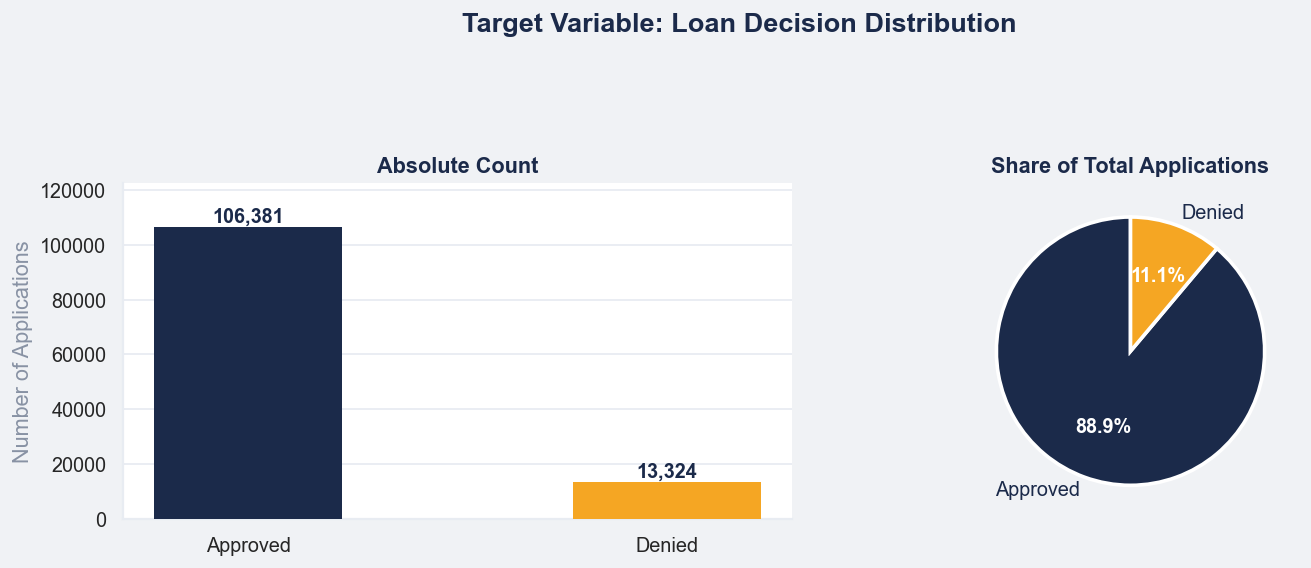

Approved : 106,381  (88.9%)
Denied   : 13,324  (11.1%)

Class imbalance ratio: 1 denied for every 7 approved


In [12]:
# ── Step 7a: Target Variable Distribution ─────────────────────────────────────
# First we visualize the class balance of our target variable.
# This is important because a heavy imbalance affects how we evaluate
# our models later — accuracy alone would be misleading.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Target Variable: Loan Decision Distribution',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)

# ── Bar chart ──────────────────────────────────────────────────────────────────
card_style(axes[0])
labels = ['Approved', 'Denied']
values = [df2['denied'].value_counts()[0], df2['denied'].value_counts()[1]]
colors = [NAVY, ORANGE]
bars   = axes[0].bar(labels, values, color=colors, width=0.45,
                     zorder=3, edgecolor='none')
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Number of Applications', color=SUBTEXT)
axes[0].yaxis.grid(True, zorder=0)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom',
                 color=TEXT, fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(values) * 1.15)

# ── Pie chart ──────────────────────────────────────────────────────────────────
card_style(axes[1])
pcts   = [df2['denied'].value_counts(normalize=True)[0] * 100,
          df2['denied'].value_counts(normalize=True)[1] * 100]
wedges, texts, autotexts = axes[1].pie(
    pcts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': CARD, 'linewidth': 2}
)
for t in texts:
    t.set_color(TEXT)
    t.set_fontsize(11)
for at in autotexts:
    at.set_color(CARD)
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Share of Total Applications')

plt.tight_layout(pad=2.5)
plt.savefig('plots/07a_target_distribution.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'Approved : {values[0]:,}  ({pcts[0]:.1f}%)')
print(f'Denied   : {values[1]:,}  ({pcts[1]:.1f}%)')
print(f'\nClass imbalance ratio: 1 denied for every {values[0]//values[1]:.0f} approved')

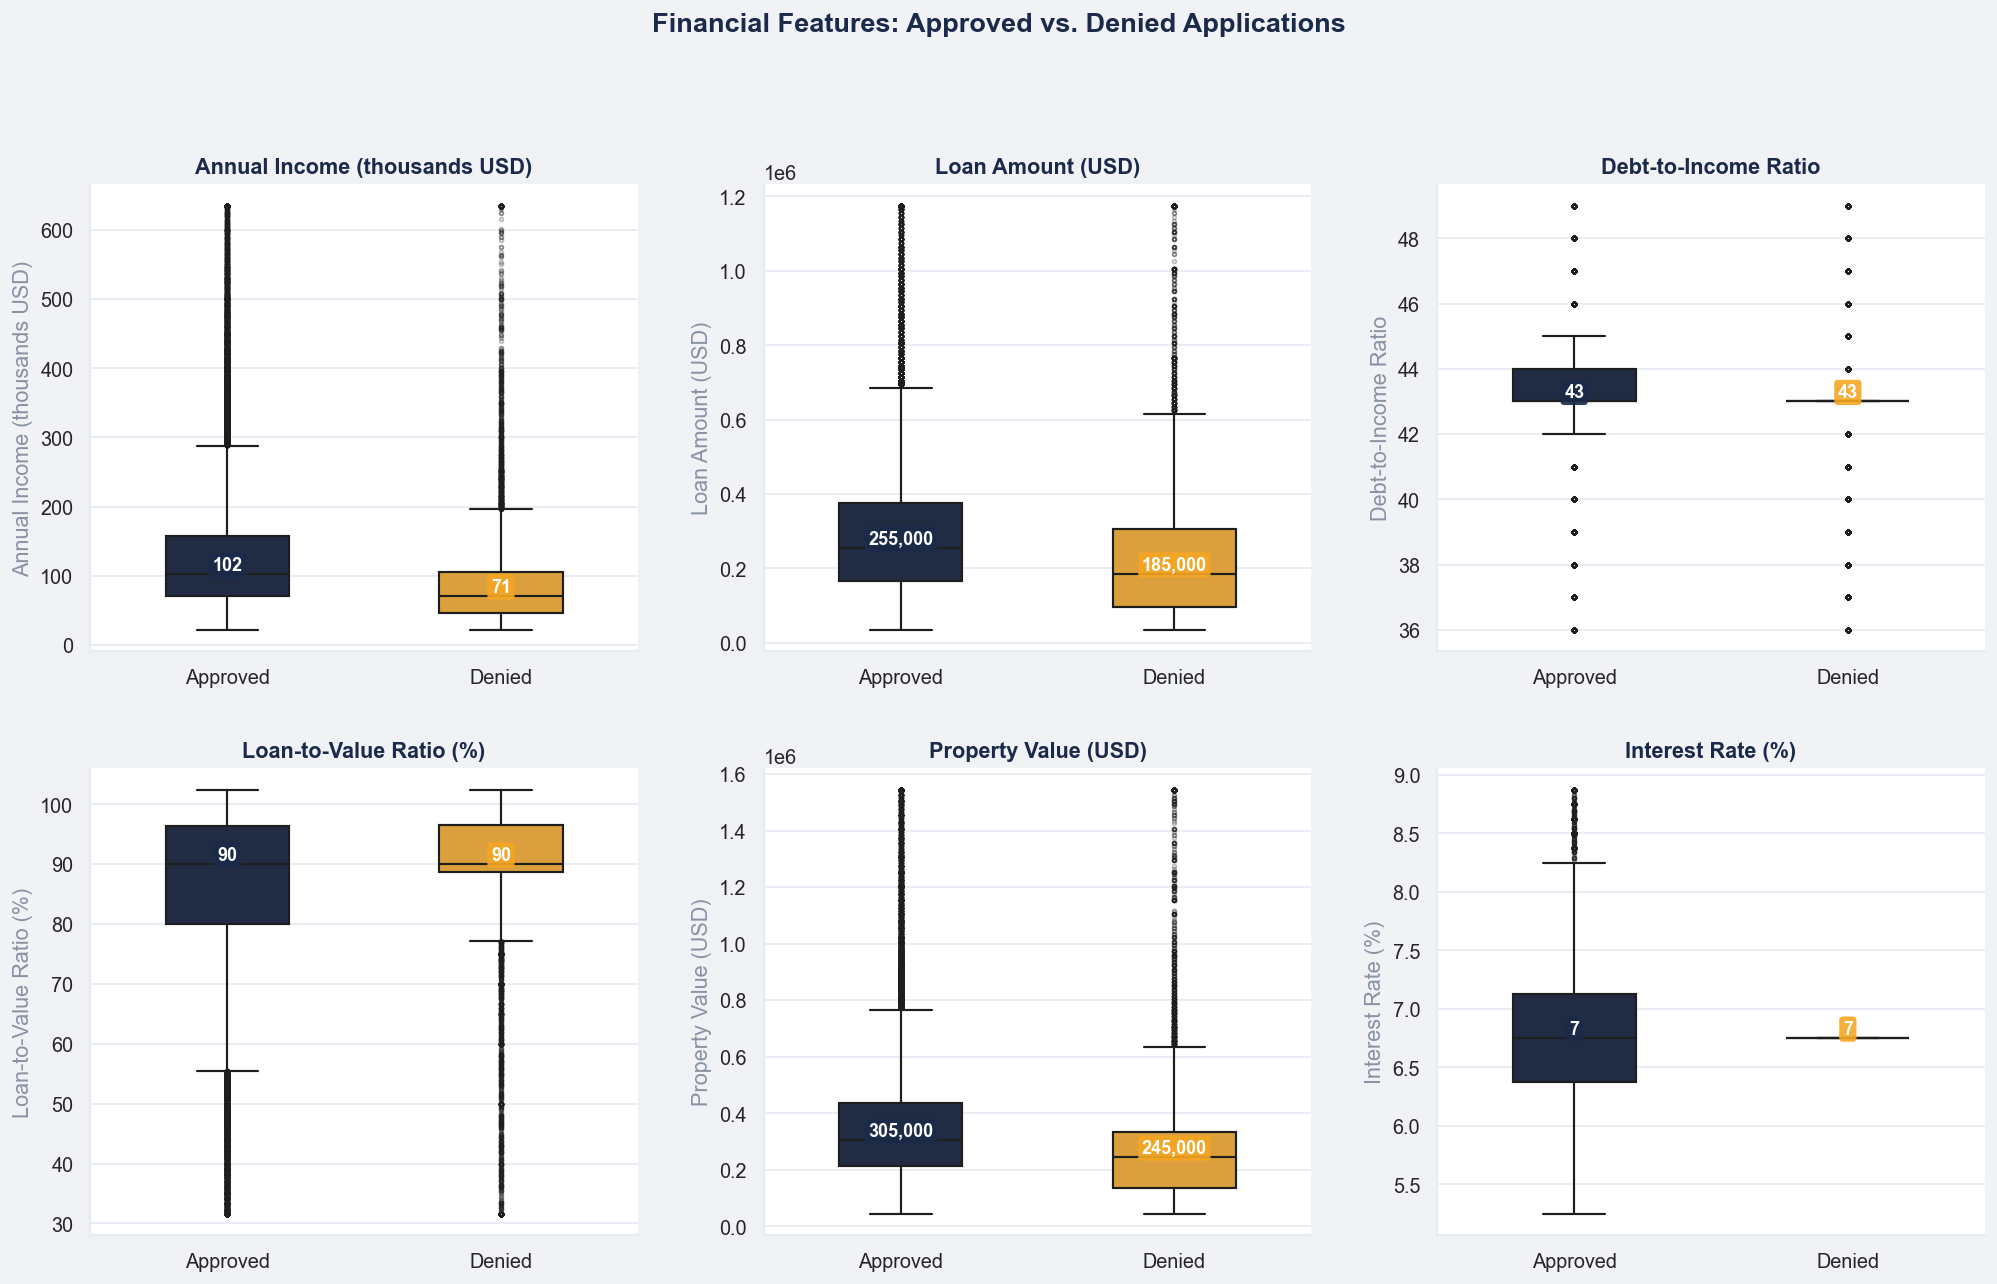

In [13]:
# ── Step 7b: Financial Features vs. Denial ───────────────────────

financial_features = {
    'income':               'Annual Income (thousands USD)',
    'loan_amount':          'Loan Amount (USD)',
    'debt_to_income_ratio': 'Debt-to-Income Ratio',
    'loan_to_value_ratio':  'Loan-to-Value Ratio (%)',
    'property_value':       'Property Value (USD)',
    'interest_rate':        'Interest Rate (%)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Financial Features: Approved vs. Denied Applications',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)

axes = axes.flatten()

for i, (col, label) in enumerate(financial_features.items()):
    card_style(axes[i])

    lo  = df2[col].quantile(0.01)
    hi  = df2[col].quantile(0.99)
    plot_df = df2[[col, 'denied']].copy()
    plot_df[col] = plot_df[col].clip(lower=lo, upper=hi)
    plot_df['Decision'] = plot_df['denied'].map({0: 'Approved', 1: 'Denied'})

    sns.boxplot(
        data=plot_df,
        x='Decision', y=col,
        order=['Approved', 'Denied'],
        palette={'Approved': NAVY, 'Denied': ORANGE},
        width=0.45,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        ax=axes[i]
    )

    # Median annotation — placed above the box with a clear background
    for j, group in enumerate(['Approved', 'Denied']):
        median = plot_df[plot_df['Decision'] == group][col].median()
        axes[i].text(
            j, median,
            f'{median:,.0f}',
            va='bottom', ha='center',
            color=CARD, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor=NAVY if group == 'Approved' else ORANGE,
                      edgecolor='none', alpha=0.9)
        )

    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(label, color=SUBTEXT)
    axes[i].yaxis.grid(True, zorder=0)

plt.tight_layout(pad=2.5)
plt.savefig('plots/07b_financial_features.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### A Note on Outliers

The box plots reveal significant outliers across all financial features.
Before continuing the EDA, we investigate and address these to ensure
they do not distort our analysis and model training.

We distinguish between three types:
- **Real extreme values** — rare but legitimate (e.g. very high income) → keep
- **Data errors** — impossible values (e.g. negative income) → remove
- **Coded placeholders** — extreme numbers used as stand-ins for missing data → remove

In [14]:
# ── Step 7b-i: Outlier Investigation ──────────────────────────────────────────
for col in financial_features.keys():
    lo = df2[col].quantile(0.01)
    hi = df2[col].quantile(0.99)
    n_low  = (df2[col] < lo).sum()
    n_high = (df2[col] > hi).sum()
    print(f'{col:<30} min: {df2[col].min():>12,.1f}  '
          f'max: {df2[col].max():>12,.1f}  '
          f'below 1%: {n_low:>5,}  above 99%: {n_high:>5,}')

income                         min:     -7,327.0  max:     20,738.0  below 1%: 1,099  above 99%: 1,194
loan_amount                    min:      5,000.0  max: 10,725,000.0  below 1%: 1,022  above 99%: 1,174
debt_to_income_ratio           min:         36.0  max:         49.0  below 1%:     0  above 99%:     0
loan_to_value_ratio            min:          3.6  max: 30,000,000.0  below 1%: 1,198  above 99%: 1,198
property_value                 min:      5,000.0  max: 86,005,000.0  below 1%:   756  above 99%: 1,193
interest_rate                  min:          0.0  max:         14.7  below 1%: 1,172  above 99%: 1,162


### Outlier Treatment

After investigating the extreme values, we apply the following treatment per column:

**`income`** — Negative values (min: -7,327) are impossible. We remove all rows where income < 0.

**`loan_amount`** — Max $10.7M is extreme and skews the model. We cap at the 99th percentile.

**`debt_to_income_ratio`** — No outliers detected. The column is already bucketed (36–49). No action needed.

**`loan_to_value_ratio`** — Max 30,000,000% is a clear data error. We cap at 120%.

**`property_value`** — Max $86M is unrealistic for owner-occupied homes. We cap at the 99th percentile.

**`interest_rate`** — Min 0% is likely a placeholder or data error. We remove all rows where interest_rate < 1%.

In [15]:
# ── Step 7b-ii: Outlier Treatment ─────────────────────────────────────────────

before = len(df2)

# income — remove negative values (data errors)
df2 = df2[df2['income'] >= 0]

# interest_rate — remove implausible values below 1%
df2 = df2[df2['interest_rate'] >= 1]

# loan_to_value_ratio — cap at 120% (anything above is a data error)
df2['loan_to_value_ratio'] = df2['loan_to_value_ratio'].clip(upper=120)

# loan_amount — cap at 99th percentile
cap_loan = df2['loan_amount'].quantile(0.99)
df2['loan_amount'] = df2['loan_amount'].clip(upper=cap_loan)

# property_value — cap at 99th percentile
cap_prop = df2['property_value'].quantile(0.99)
df2['property_value'] = df2['property_value'].clip(upper=cap_prop)

df2 = df2.reset_index(drop=True)
after = len(df2)

print(f'Rows removed : {before - after:,}')
print(f'Rows remaining: {after:,}')

Rows removed : 42
Rows remaining: 119,663


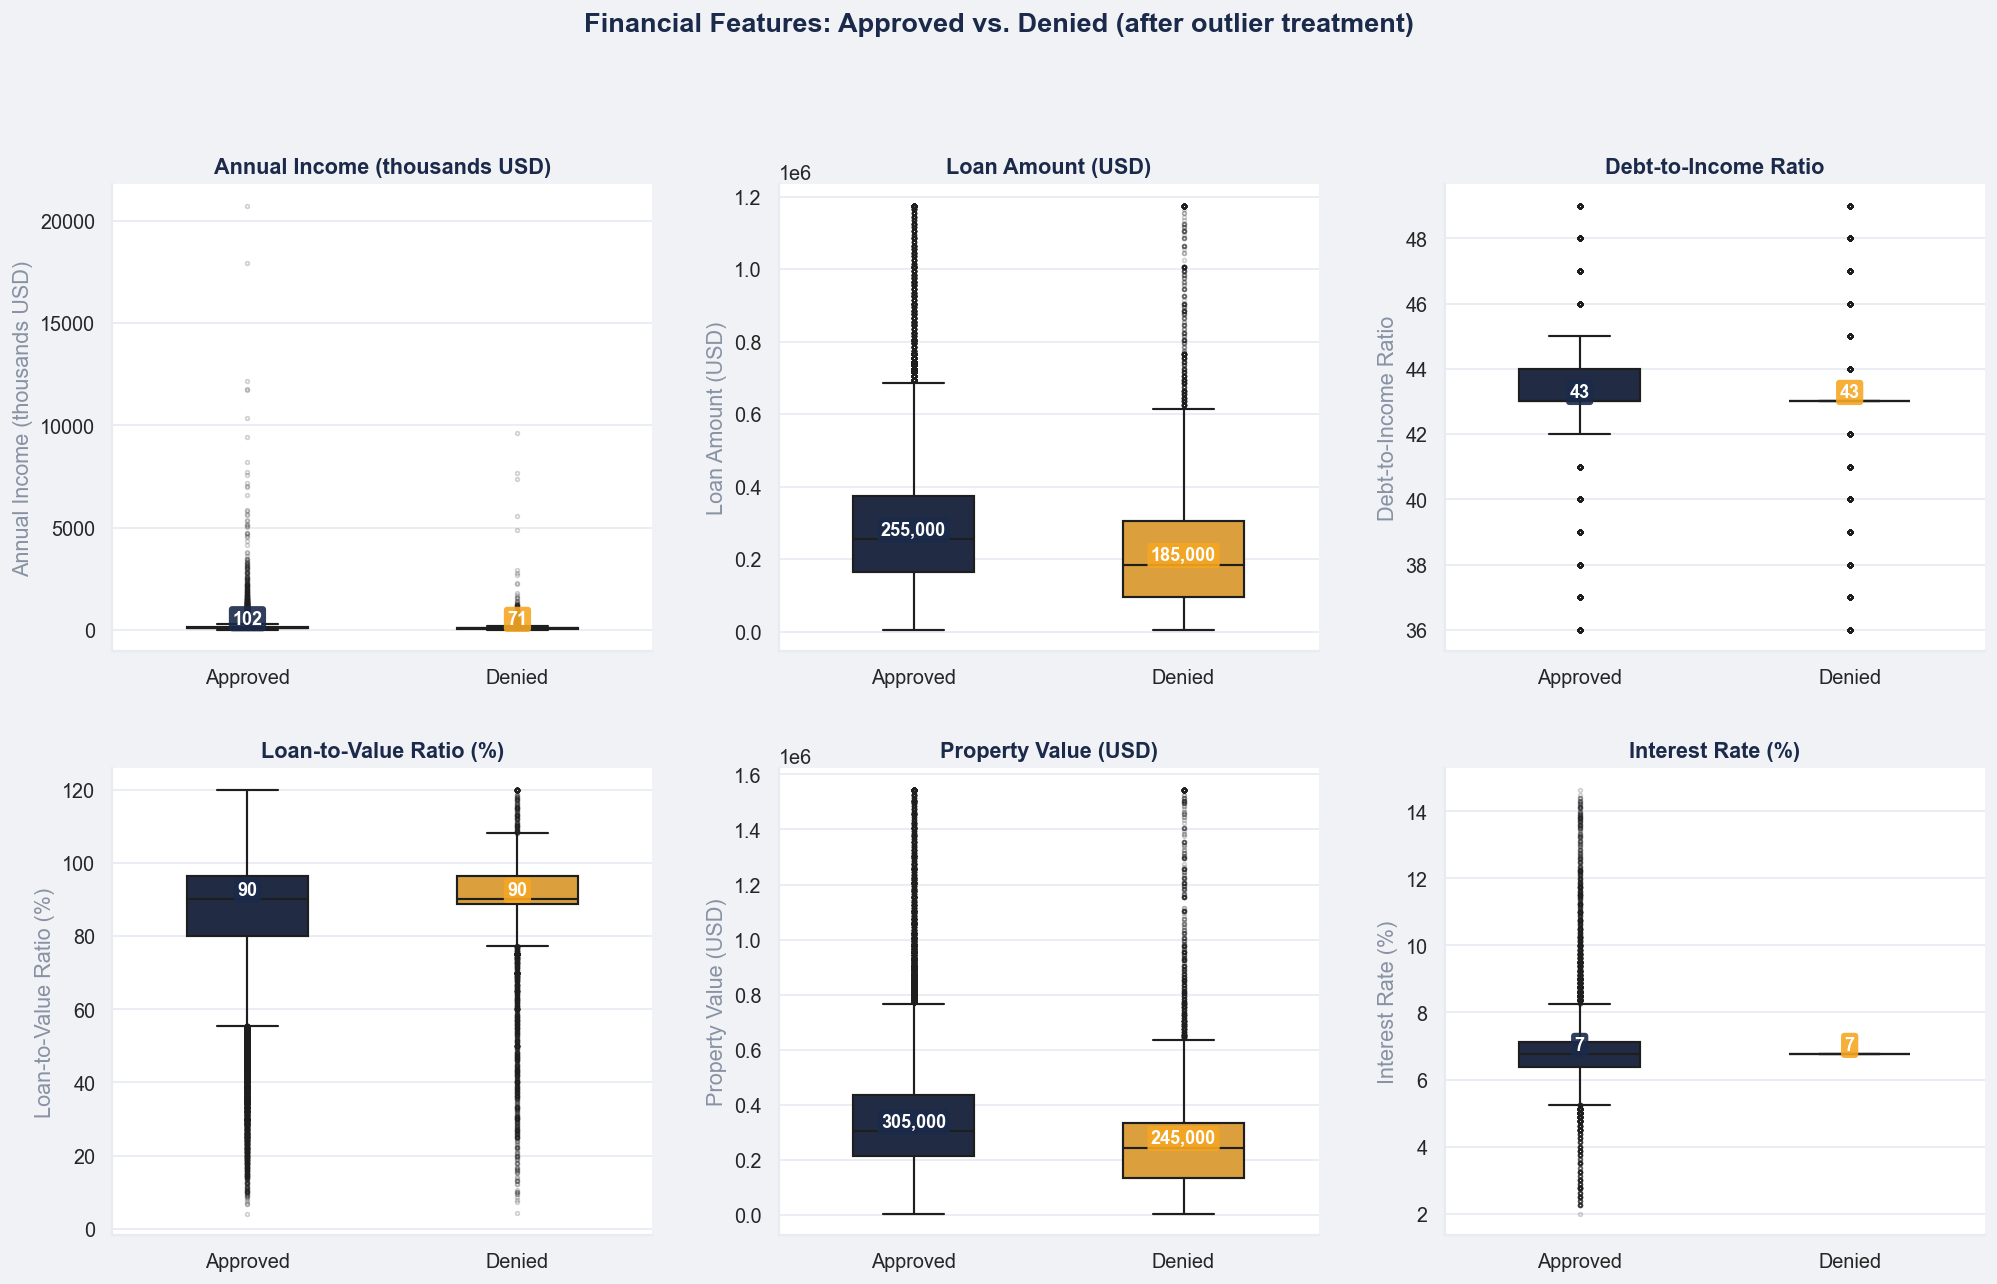

In [16]:
# ── Step 7b-iii: Financial Features vs. Denial (after outlier treatment) ───────
# We re-plot the box plots after outlier treatment to confirm the distributions
# are now clean and comparable between approved and denied applications.

financial_features = {
    'income':               'Annual Income (thousands USD)',
    'loan_amount':          'Loan Amount (USD)',
    'debt_to_income_ratio': 'Debt-to-Income Ratio',
    'loan_to_value_ratio':  'Loan-to-Value Ratio (%)',
    'property_value':       'Property Value (USD)',
    'interest_rate':        'Interest Rate (%)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Financial Features: Approved vs. Denied (after outlier treatment)',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)

axes = axes.flatten()

for i, (col, label) in enumerate(financial_features.items()):
    card_style(axes[i])

    plot_df = df2[[col, 'denied']].copy()
    plot_df['Decision'] = plot_df['denied'].map({0: 'Approved', 1: 'Denied'})

    sns.boxplot(
        data=plot_df,
        x='Decision', y=col,
        order=['Approved', 'Denied'],
        palette={'Approved': NAVY, 'Denied': ORANGE},
        width=0.45,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.2),
        ax=axes[i]
    )

    # Median annotation
    for j, group in enumerate(['Approved', 'Denied']):
        median = plot_df[plot_df['Decision'] == group][col].median()
        axes[i].text(
            j, median,
            f'{median:,.0f}',
            va='bottom', ha='center',
            color=CARD, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor=NAVY if group == 'Approved' else ORANGE,
                      edgecolor='none', alpha=0.9)
        )

    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(label, color=SUBTEXT)
    axes[i].yaxis.grid(True, zorder=0)

plt.tight_layout(pad=2.5)
plt.savefig('plots/07b_financial_features_clean.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### Key Insights: Financial Features

The box plots reveal several interesting patterns between approved and denied applications.

**Income and loan amount drive approvals most visibly.**
Approved applicants earn a median of 102k/year vs. 71k for denied applicants — a gap of roughly 30%.
Similarly, approved loans are for higher amounts (255k vs. 185k), suggesting that denied applicants
tend to apply for smaller loans relative to what lenders are willing to approve.

**Property value follows the same pattern.**
Approved applications involve higher-value properties (305k vs. 245k median), which likely reflects
the income gap — wealthier applicants buy more expensive homes and get approved more easily.

**DTI, LTV and interest rate show surprisingly little difference.**
Both groups share a median DTI of 43 and an interest rate of 7%. The loan-to-value ratio is also
nearly identical at 90% for both groups. This suggests that these metrics alone do not drive denial
decisions — or that lenders apply them consistently regardless of outcome.

**Takeaway:** Financial strength (income, loan size, property value) differentiates approved from
denied applicants more than risk ratios (DTI, LTV). This raises the question: if financial ratios
are similar across groups, what else is driving denials? This is exactly what the fairness analysis
will explore.

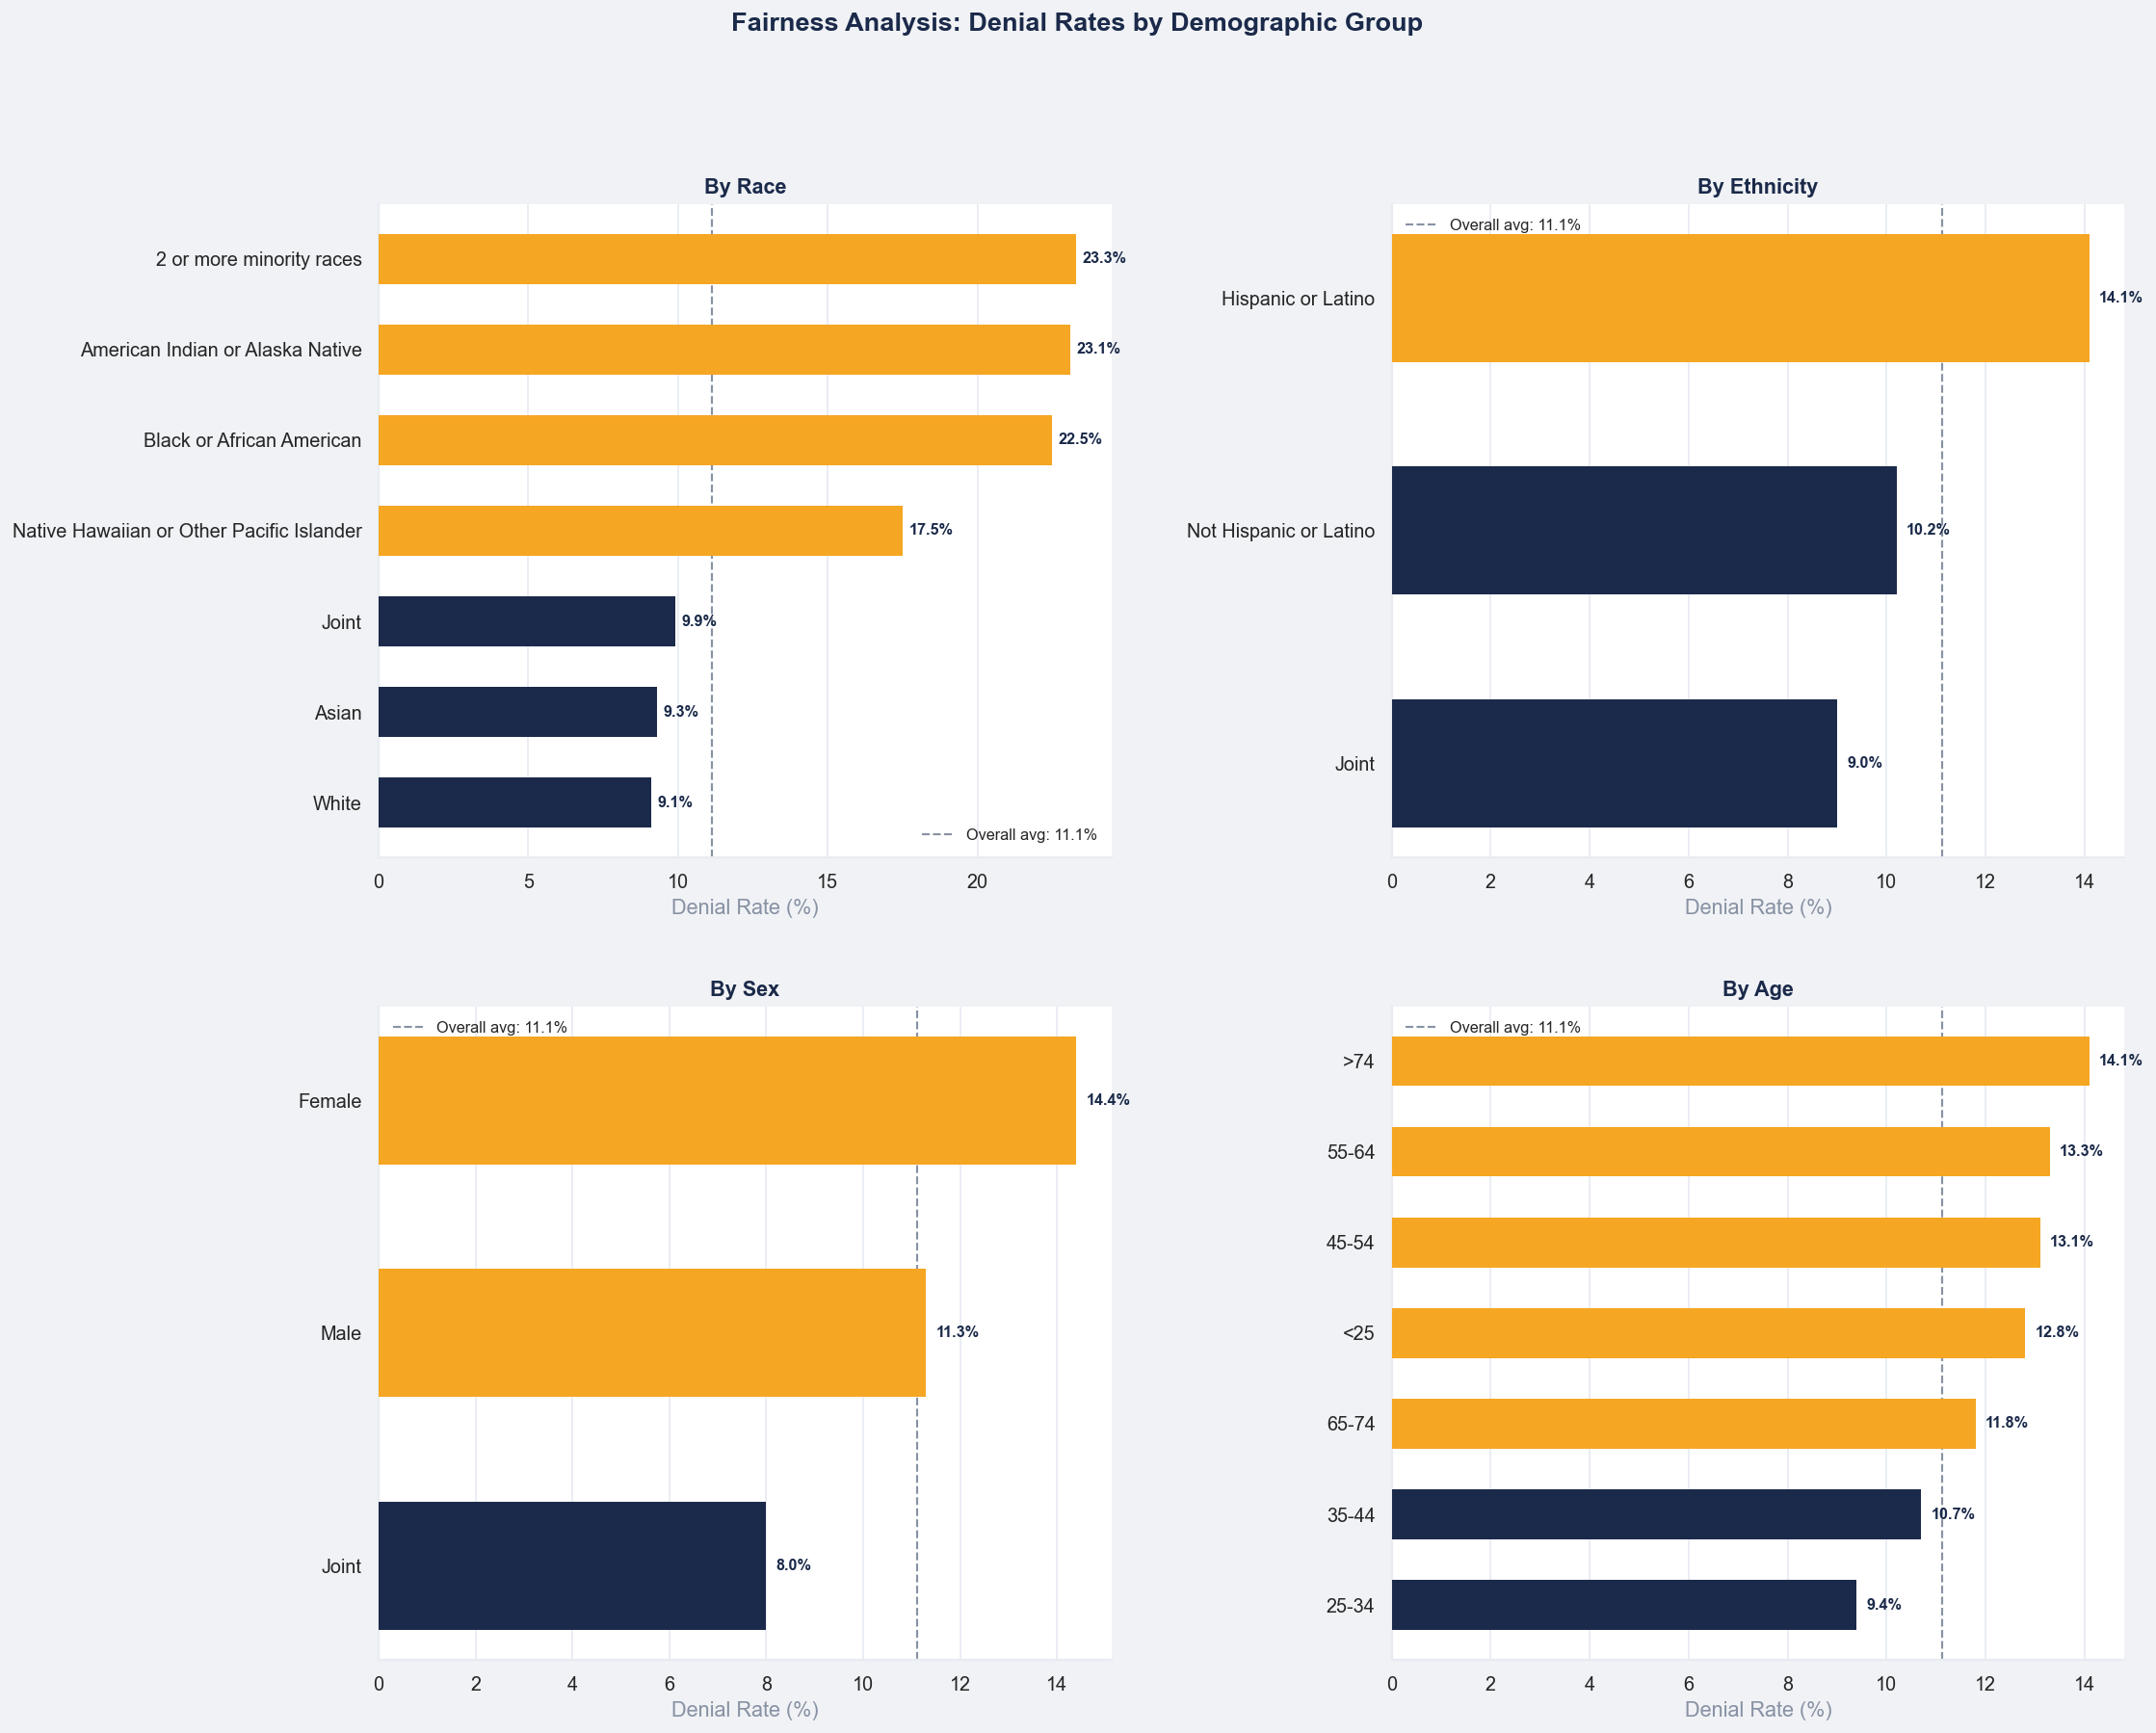

In [17]:
# ── Step 7c: Fairness Analysis (revised) ──────────────────────────────────────
# We examine denial rates across all four demographic dimensions:
# race, ethnicity, sex, and age — in a single 2x2 layout.

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor(BG)
fig.suptitle('Fairness Analysis: Denial Rates by Demographic Group',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)

axes = axes.flatten()
overall_avg = df2['denied'].mean() * 100

# ── Helper function ────────────────────────────────────────────────────────────
def denial_bar(ax, col, title, exclude=[]):
    card_style(ax)
    denial = (df2.groupby(col)['denied']
              .mean()
              .mul(100)
              .round(1)
              .sort_values(ascending=True)
              .reset_index())
    denial.columns = ['Group', 'Denial Rate']
    denial = denial[~denial['Group'].isin(exclude)]

    colors = [ORANGE if r > overall_avg else NAVY
              for r in denial['Denial Rate']]

    bars = ax.barh(denial['Group'], denial['Denial Rate'],
                   color=colors, height=0.55, zorder=3, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel('Denial Rate (%)', color=SUBTEXT)
    ax.xaxis.grid(True, zorder=0)
    ax.axvline(overall_avg, color=SUBTEXT, linewidth=1.2,
               linestyle='--', label=f'Overall avg: {overall_avg:.1f}%')
    ax.legend(fontsize=9, frameon=False)
    for bar, val in zip(bars, denial['Denial Rate']):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', color=TEXT,
                fontsize=9, fontweight='bold')

# ── Race ───────────────────────────────────────────────────────────────────────
denial_bar(axes[0], 'derived_race', 'By Race',
           exclude=['Race Not Available', 'Free Form Text Only'])

# ── Ethnicity ──────────────────────────────────────────────────────────────────
denial_bar(axes[1], 'derived_ethnicity', 'By Ethnicity',
           exclude=['Ethnicity Not Available', 'Free Form Text Only'])

# ── Sex ────────────────────────────────────────────────────────────────────────
denial_bar(axes[2], 'derived_sex', 'By Sex',
           exclude=['Sex Not Available'])

# ── Age ────────────────────────────────────────────────────────────────────────
denial_bar(axes[3], 'applicant_age', 'By Age',
           exclude=['8888'])

plt.tight_layout(pad=3.0)
plt.savefig('plots/07c_fairness_demographics.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### Key Insights: Fairness Analysis by Demographic Group

The 2x2 panel reveals consistent patterns of disparity across all four
demographic dimensions. The dashed line marks the overall average denial
rate of 11.1% for reference.

**Race shows the strongest disparities.**
Black or African American applicants face a denial rate of 22.5%, and American Indian
or Alaska Native applicants 23.1% — more than double the rate for White applicants (9.1%).
Asian applicants are closest to White applicants at 9.3%. Joint applications show a
lower rate of 9.9%, suggesting that having a co-applicant reduces denial risk.

**Ethnicity follows a similar pattern.**
Hispanic or Latino applicants are denied at 14.1% — nearly 40% higher than
Non-Hispanic or Latino applicants at 10.2%. Joint applications again show
the lowest rate at 9.0%.

**Sex shows a notable gap.**
Female applicants face a denial rate of 14.4% vs. 11.3% for male applicants —
both above the overall average. Joint applications have the lowest rate at 8.0%,
reinforcing the pattern that two-applicant households are financially stronger
and get approved more easily.

**Age reveals a U-shaped pattern.**
The youngest (<25) and oldest (>74) applicants face the highest denial rates
(12.8% and 14.1% respectively), while applicants aged 25-34 enjoy the lowest
rate at 9.4%. Mid-career applicants (35-44) also perform well at 10.7%.
This likely reflects income stability — younger applicants have shorter credit
histories and lower incomes, while older applicants may be retired with
lower reported income.

**Takeaway:** Disparity is consistent across all demographic dimensions.
Minority racial groups, Hispanic applicants, female applicants, and applicants
at the extremes of the age spectrum all face above-average denial rates.
Whether these gaps reflect legitimate financial differences or structural bias
is the central question our model will help answer.

---

### A Note on Redlining

Redlining refers to the historic practice of denying mortgage loans to applicants
based on the racial composition of their neighborhood rather than their individual
financial merit. The term originates from the 1930s, when US agencies literally
drew red lines around minority neighborhoods on city maps to flag them as
"high risk" for lenders.

Although officially banned by the Fair Housing Act in 1968, researchers and
regulators continue to investigate whether modern forms of redlining persist —
i.e. whether applicants in minority-heavy neighborhoods face higher denial rates
even when their financial profile is identical to applicants in other areas.

Our dataset includes `tract_minority_population_percent` — the share of minority
residents in the applicant's census tract — which allows us to test this directly.

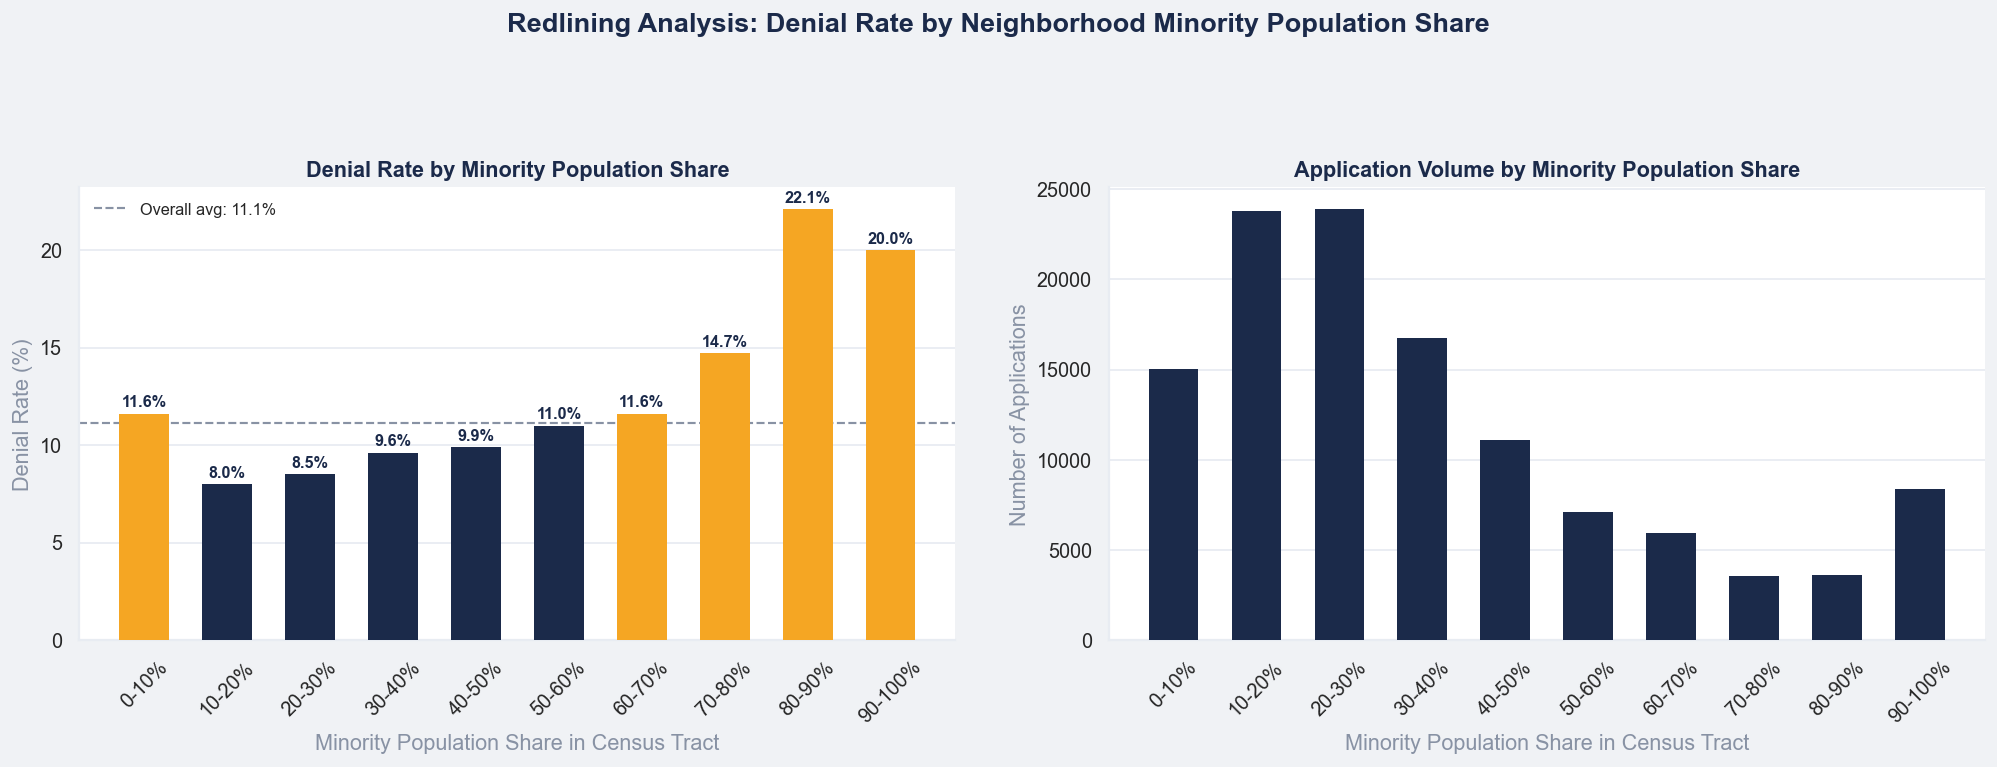

Minority %  Denial Rate  Count
     0-10%         11.6  15030
    10-20%          8.0  23774
    20-30%          8.5  23900
    30-40%          9.6  16750
    40-50%          9.9  11074
    50-60%         11.0   7092
    60-70%         11.6   5954
    70-80%         14.7   3538
    80-90%         22.1   3609
   90-100%         20.0   8393


In [18]:
# ── Step 7d: Redlining Analysis ────────────────────────────────────────────────
# We examine whether denial rates increase as the minority population share
# of the applicant's census tract increases. If so, this is a signal of
# modern redlining — neighborhood composition influencing loan decisions
# independently of the applicant's financial profile.

# Bin tract_minority_population_percent into deciles for readability
df2['minority_pct_bin'] = pd.cut(
    df2['tract_minority_population_percent'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
            '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
)

redlining = (df2.groupby('minority_pct_bin', observed=True)['denied']
             .agg(['mean', 'count'])
             .reset_index())
redlining.columns = ['Minority %', 'Denial Rate', 'Count']
redlining['Denial Rate'] = (redlining['Denial Rate'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Redlining Analysis: Denial Rate by Neighborhood Minority Population Share',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)

# ── Bar chart: denial rate per bin ────────────────────────────────────────────
card_style(axes[0])
bar_colors = [ORANGE if r > overall_avg else NAVY
              for r in redlining['Denial Rate']]
bars = axes[0].bar(redlining['Minority %'], redlining['Denial Rate'],
                   color=bar_colors, width=0.6, zorder=3, edgecolor='none')
axes[0].axhline(overall_avg, color=SUBTEXT, linewidth=1.2,
                linestyle='--', label=f'Overall avg: {overall_avg:.1f}%')
axes[0].set_title('Denial Rate by Minority Population Share')
axes[0].set_xlabel('Minority Population Share in Census Tract', color=SUBTEXT)
axes[0].set_ylabel('Denial Rate (%)', color=SUBTEXT)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.grid(True, zorder=0)
axes[0].legend(fontsize=9, frameon=False)
for bar, val in zip(bars, redlining['Denial Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val}%', ha='center', va='bottom',
                 color=TEXT, fontsize=9, fontweight='bold')

# ── Bar chart: application volume per bin ─────────────────────────────────────
card_style(axes[1])
axes[1].bar(redlining['Minority %'], redlining['Count'],
            color=NAVY, width=0.6, zorder=3, edgecolor='none')
axes[1].set_title('Application Volume by Minority Population Share')
axes[1].set_xlabel('Minority Population Share in Census Tract', color=SUBTEXT)
axes[1].set_ylabel('Number of Applications', color=SUBTEXT)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.grid(True, zorder=0)

plt.tight_layout(pad=2.5)
plt.savefig('plots/07d_redlining.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

# Print summary table
print(redlining.to_string(index=False))

### Key Insights: Redlining Analysis

The results reveal a clear and troubling pattern: denial rates rise sharply
as the minority population share of the census tract increases.

**A clear gradient emerges.**
In tracts where minorities make up less than 20% of the population, denial rates
are well below the overall average — just 8.0% and 8.5% for the 10-20% and 20-30%
bins respectively. As the minority share grows, denial rates climb steadily —
reaching 22.1% in tracts that are 80-90% minority, and 20.0% in tracts that are
90-100% minority. That is nearly three times the rate of predominantly white neighborhoods.

**Application volume is concentrated in mixed neighborhoods.**
The right panel shows that most applications come from tracts with 10-40% minority
population. Heavily minority neighborhoods (70-100%) see far fewer applications —
which itself may reflect a legacy of historic redlining discouraging homeownership
in these communities.

**Takeaway:** The neighborhood's minority composition is strongly associated with
denial rates — independent of the individual applicant's financial profile.
This is a textbook signal of modern redlining and aligns with findings from
recent CFPB enforcement actions. Whether this effect persists after controlling
for financial features will be a key question in the modeling phase.

---
### A Note on Loan Types

Not all mortgage loans are the same. In the US mortgage market, there are
four main types of home loans, each serving a different borrower profile:

**Conventional** — A standard bank loan with no government backing. The lender
takes on the full risk. Typically requires a good credit score and a down payment
of at least 20%. The most common loan type.

**FHA (Federal Housing Administration)** — A government-insured loan where the
US federal government guarantees repayment to the bank if the borrower defaults.
This allows banks to lend to buyers with lower credit scores and down payments
as low as 3.5%. Commonly used by first-time buyers and lower-income households.

**VA (Veterans Affairs)** — A government-backed loan exclusively available to
US military veterans and active service members. Often requires no down payment
and offers favorable terms. Administered by the Department of Veterans Affairs.

**USDA (US Department of Agriculture)** — A government-backed loan for
low-to-moderate income buyers in rural and suburban areas. Also requires
no down payment. Administered by the US Department of Agriculture.

The key distinction for our analysis: FHA and USDA loans are specifically
designed to make homeownership accessible to financially vulnerable borrowers —
yet as we will see, they face the highest denial rates in our dataset.

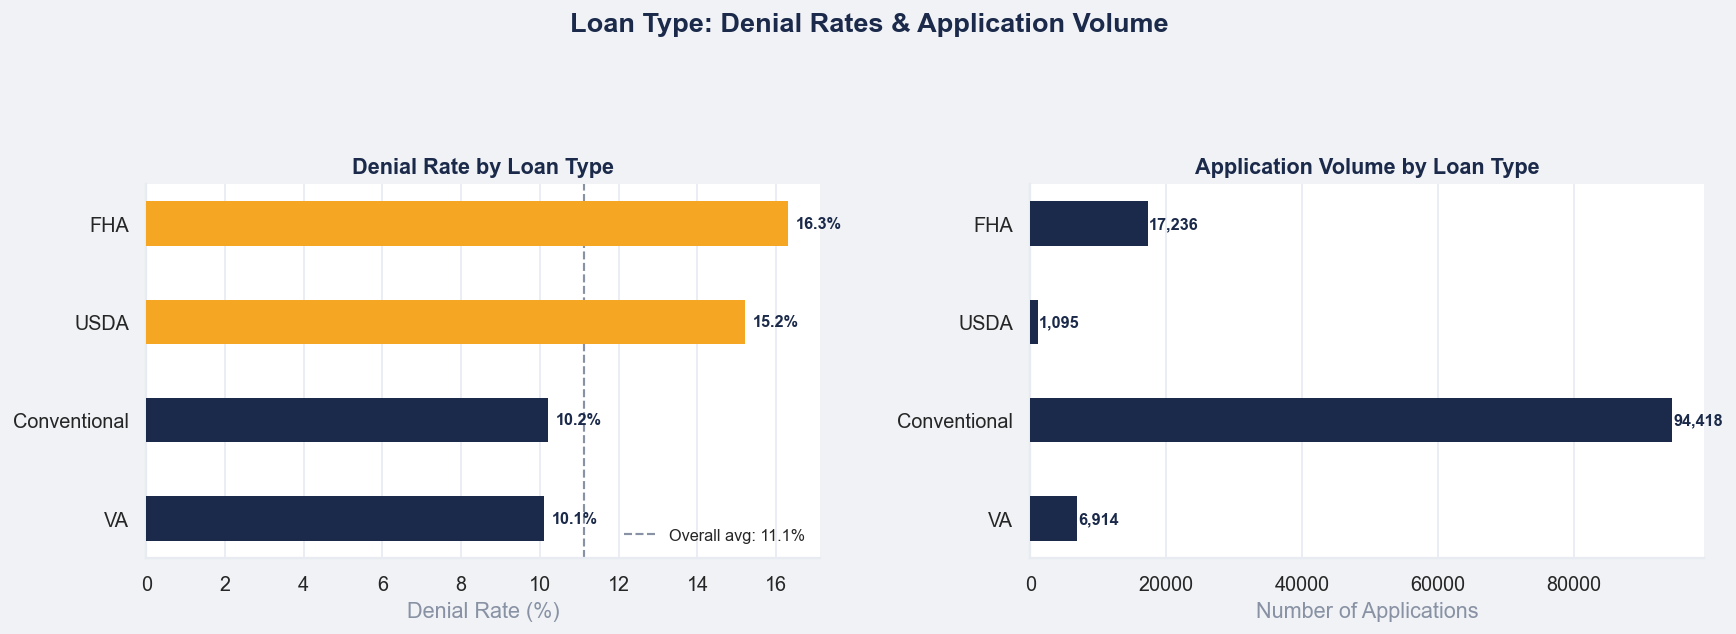

In [19]:
# ── Step 7e: Loan Type vs. Denial ─────────────────────────────────────────────
# We examine whether denial rates differ across loan types.
# FHA and USDA loans serve lower-income and minority borrowers —
# if they face higher denial rates, this may partially explain
# the demographic disparities observed in the fairness analysis.

loan_type_map = {
    1: 'Conventional',
    2: 'FHA',
    3: 'VA',
    4: 'USDA'
}

df2['loan_type_label'] = df2['loan_type'].map(loan_type_map)

loan_denial = (df2.groupby('loan_type_label')['denied']
               .agg(['mean', 'count'])
               .reset_index())
loan_denial.columns = ['Loan Type', 'Denial Rate', 'Count']
loan_denial['Denial Rate'] = (loan_denial['Denial Rate'] * 100).round(1)
loan_denial = loan_denial.sort_values('Denial Rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Loan Type: Denial Rates & Application Volume',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)

# ── Denial Rate ────────────────────────────────────────────────────────────────
card_style(axes[0])
bar_colors = [ORANGE if r > overall_avg else NAVY
              for r in loan_denial['Denial Rate']]
bars = axes[0].barh(loan_denial['Loan Type'], loan_denial['Denial Rate'],
                    color=bar_colors, height=0.45, zorder=3, edgecolor='none')
axes[0].axvline(overall_avg, color=SUBTEXT, linewidth=1.2,
                linestyle='--', label=f'Overall avg: {overall_avg:.1f}%')
axes[0].set_title('Denial Rate by Loan Type')
axes[0].set_xlabel('Denial Rate (%)', color=SUBTEXT)
axes[0].xaxis.grid(True, zorder=0)
axes[0].legend(fontsize=9, frameon=False)
for bar, val in zip(bars, loan_denial['Denial Rate']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', color=TEXT,
                 fontsize=9, fontweight='bold')

# ── Application Volume ─────────────────────────────────────────────────────────
card_style(axes[1])
axes[1].barh(loan_denial['Loan Type'], loan_denial['Count'],
             color=NAVY, height=0.45, zorder=3, edgecolor='none')
axes[1].set_title('Application Volume by Loan Type')
axes[1].set_xlabel('Number of Applications', color=SUBTEXT)
axes[1].xaxis.grid(True, zorder=0)
for i, (_, row) in enumerate(loan_denial.iterrows()):
    axes[1].text(row['Count'] + 200, i,
                 f'{row["Count"]:,}', va='center', color=TEXT,
                 fontsize=9, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('plots/07e_loan_type.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### Key Insights: Loan Type

The results reveal a clear two-tier pattern in denial rates across loan types.

**FHA and USDA loans face significantly higher denial rates.**
FHA loans — designed for lower-income and first-time buyers — are denied at 16.3%,
well above the overall average of 11.1%. USDA loans, targeting rural low-income
borrowers, follow at 15.2%. Both serve economically vulnerable populations,
yet face the highest rejection rates.

**Conventional and VA loans perform close to or below average.**
Conventional loans (10.2%) and VA loans (10.1%) — the latter exclusively for
military veterans — are denied at rates below the overall average, despite
conventional loans having stricter financial requirements.

**Volume is dominated by conventional loans.**
94,418 out of 119,663 applications are conventional — nearly 79% of all applications.
FHA accounts for 17,236 (14%), VA for 6,914 (6%), and USDA for just 1,095 (1%).

**Takeaway:** The loan types with the highest denial rates are precisely those
designed to help disadvantaged borrowers enter the housing market. Combined with
our earlier finding that minority applicants face higher denial rates, this raises
the question of whether loan type partially mediates the demographic disparities
we observed — i.e. minority applicants may disproportionately apply for FHA loans
and therefore face higher denial rates for structural rather than discriminatory reasons.
The model will help disentangle these effects.

---

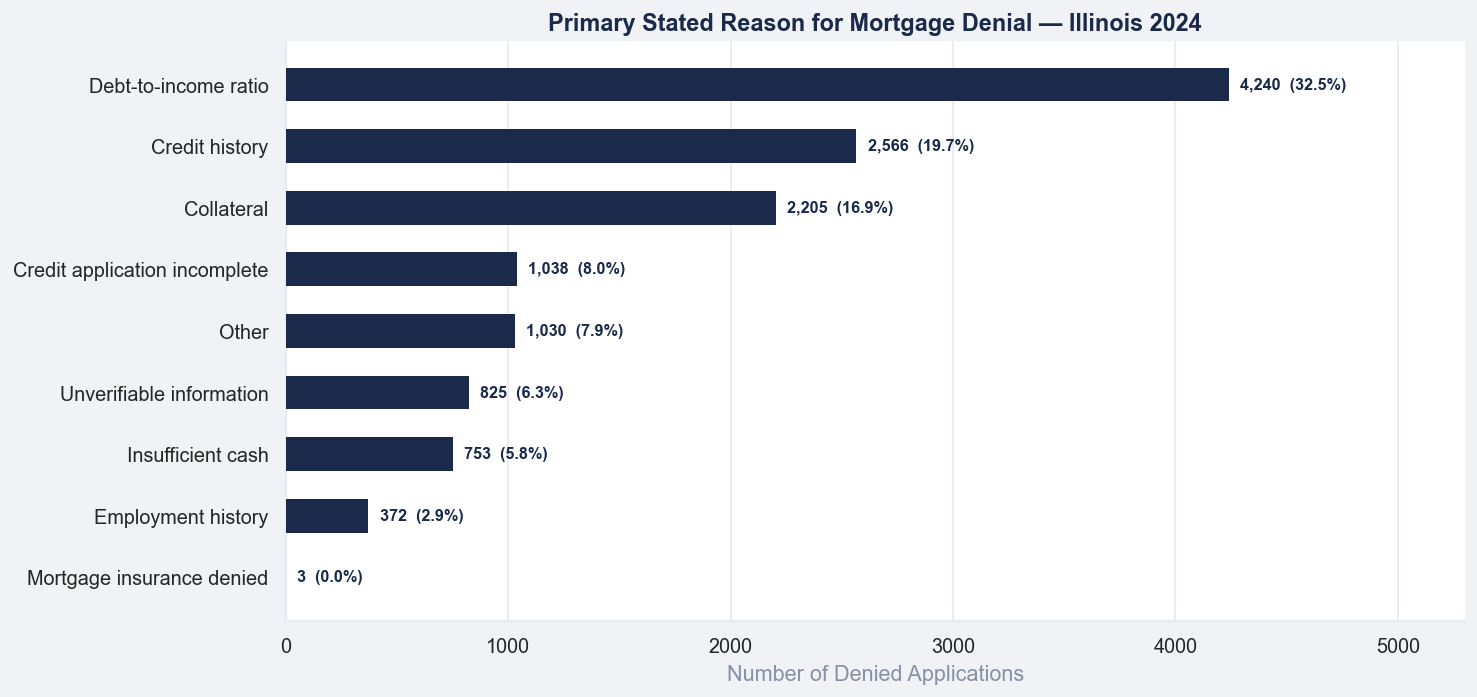

                       Reason  Count  Share
    Mortgage insurance denied      3    0.0
           Employment history    372    2.9
            Insufficient cash    753    5.8
     Unverifiable information    825    6.3
                        Other   1030    7.9
Credit application incomplete   1038    8.0
                   Collateral   2205   16.9
               Credit history   2566   19.7
         Debt-to-income ratio   4240   32.5


In [20]:
# ── Step 7f: Denial Reasons ────────────────────────────────────────────────────
# The dataset includes the officially stated reason for each denial.
# We use this for exploratory purposes only — it cannot be used in the model
# because it is post-decision information (data leakage).
# It does however give us valuable context on what banks officially cite
# as the reason for rejecting an application.

# Load denial reasons from the original filtered data
# We need df0 here since we dropped denial_reason-1 earlier
denial_reason_map = {
    1:  'Debt-to-income ratio',
    2:  'Employment history',
    3:  'Credit history',
    4:  'Collateral',
    5:  'Insufficient cash',
    6:  'Unverifiable information',
    7:  'Credit application incomplete',
    8:  'Mortgage insurance denied',
    9:  'Other',
    10: 'Exempt'
}

# Reload denial reason from df0, aligned to our filtered index
dr = df0.loc[df2.index, 'denial_reason-1'].copy() if False else None

# Re-merge from original data using the scope filter
df_denied = df0[
    (df0['loan_purpose']   == 1) &
    (df0['lien_status']    == 1) &
    (df0['occupancy_type'] == 1) &
    (df0['action_taken']   == 3)
][['denial_reason-1']].copy()

df_denied['denial_reason_label'] = df_denied['denial_reason-1'].map(denial_reason_map)

reason_counts = (df_denied['denial_reason_label']
                 .value_counts()
                 .reset_index())
reason_counts.columns = ['Reason', 'Count']
reason_counts['Share'] = (reason_counts['Count'] / reason_counts['Count'].sum() * 100).round(1)

# Remove exempt
reason_counts = reason_counts[reason_counts['Reason'] != 'Exempt']
reason_counts = reason_counts.sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
card_style(ax)

bars = ax.barh(reason_counts['Reason'], reason_counts['Count'],
               color=NAVY, height=0.55, zorder=3, edgecolor='none')
ax.set_title('Primary Stated Reason for Mortgage Denial — Illinois 2024',
             fontsize=13, fontweight='bold', color=TEXT)
ax.set_xlabel('Number of Denied Applications', color=SUBTEXT)
ax.xaxis.grid(True, zorder=0)

for bar, (_, row) in zip(bars, reason_counts.iterrows()):
    ax.text(row['Count'] + 50,
            bar.get_y() + bar.get_height()/2,
            f'{row["Count"]:,}  ({row["Share"]}%)',
            va='center', color=TEXT, fontsize=9, fontweight='bold')

ax.set_xlim(0, reason_counts['Count'].max() * 1.25)

plt.tight_layout(pad=2.5)
plt.savefig('plots/07f_denial_reasons.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

print(reason_counts.to_string(index=False))

### Key Insights: Denial Reasons

The officially stated reasons for denial reveal which financial factors
banks cite most frequently when rejecting mortgage applications.

**Debt-to-income ratio is the single biggest reason for denial.**
32.5% of all denied applications cite DTI as the primary reason — nearly
one in three rejections. This means the applicant's total debt burden relative
to their income was deemed too high to service the loan safely.

**Credit history and collateral follow at a distance.**
Credit history accounts for 19.7% of denials, and collateral — meaning the
property value was deemed insufficient to secure the loan — for 16.9%.
Together with DTI, these three reasons explain nearly 70% of all denials.

**Process-related reasons account for a notable share.**
8.0% of denials stem from incomplete applications and 6.3% from unverifiable
information — suggesting that a meaningful portion of rejections could
potentially be avoided with better applicant guidance.

**Important caveat:** These are the reasons banks officially report —
they do not necessarily reflect the full picture. Lenders are not required
to cite demographic factors, and our earlier fairness analysis showed that
denial rates vary significantly by race, ethnicity, and sex even when
financial profiles are similar. The model will help us assess whether
financial reasons alone can explain the demographic disparities we observed.

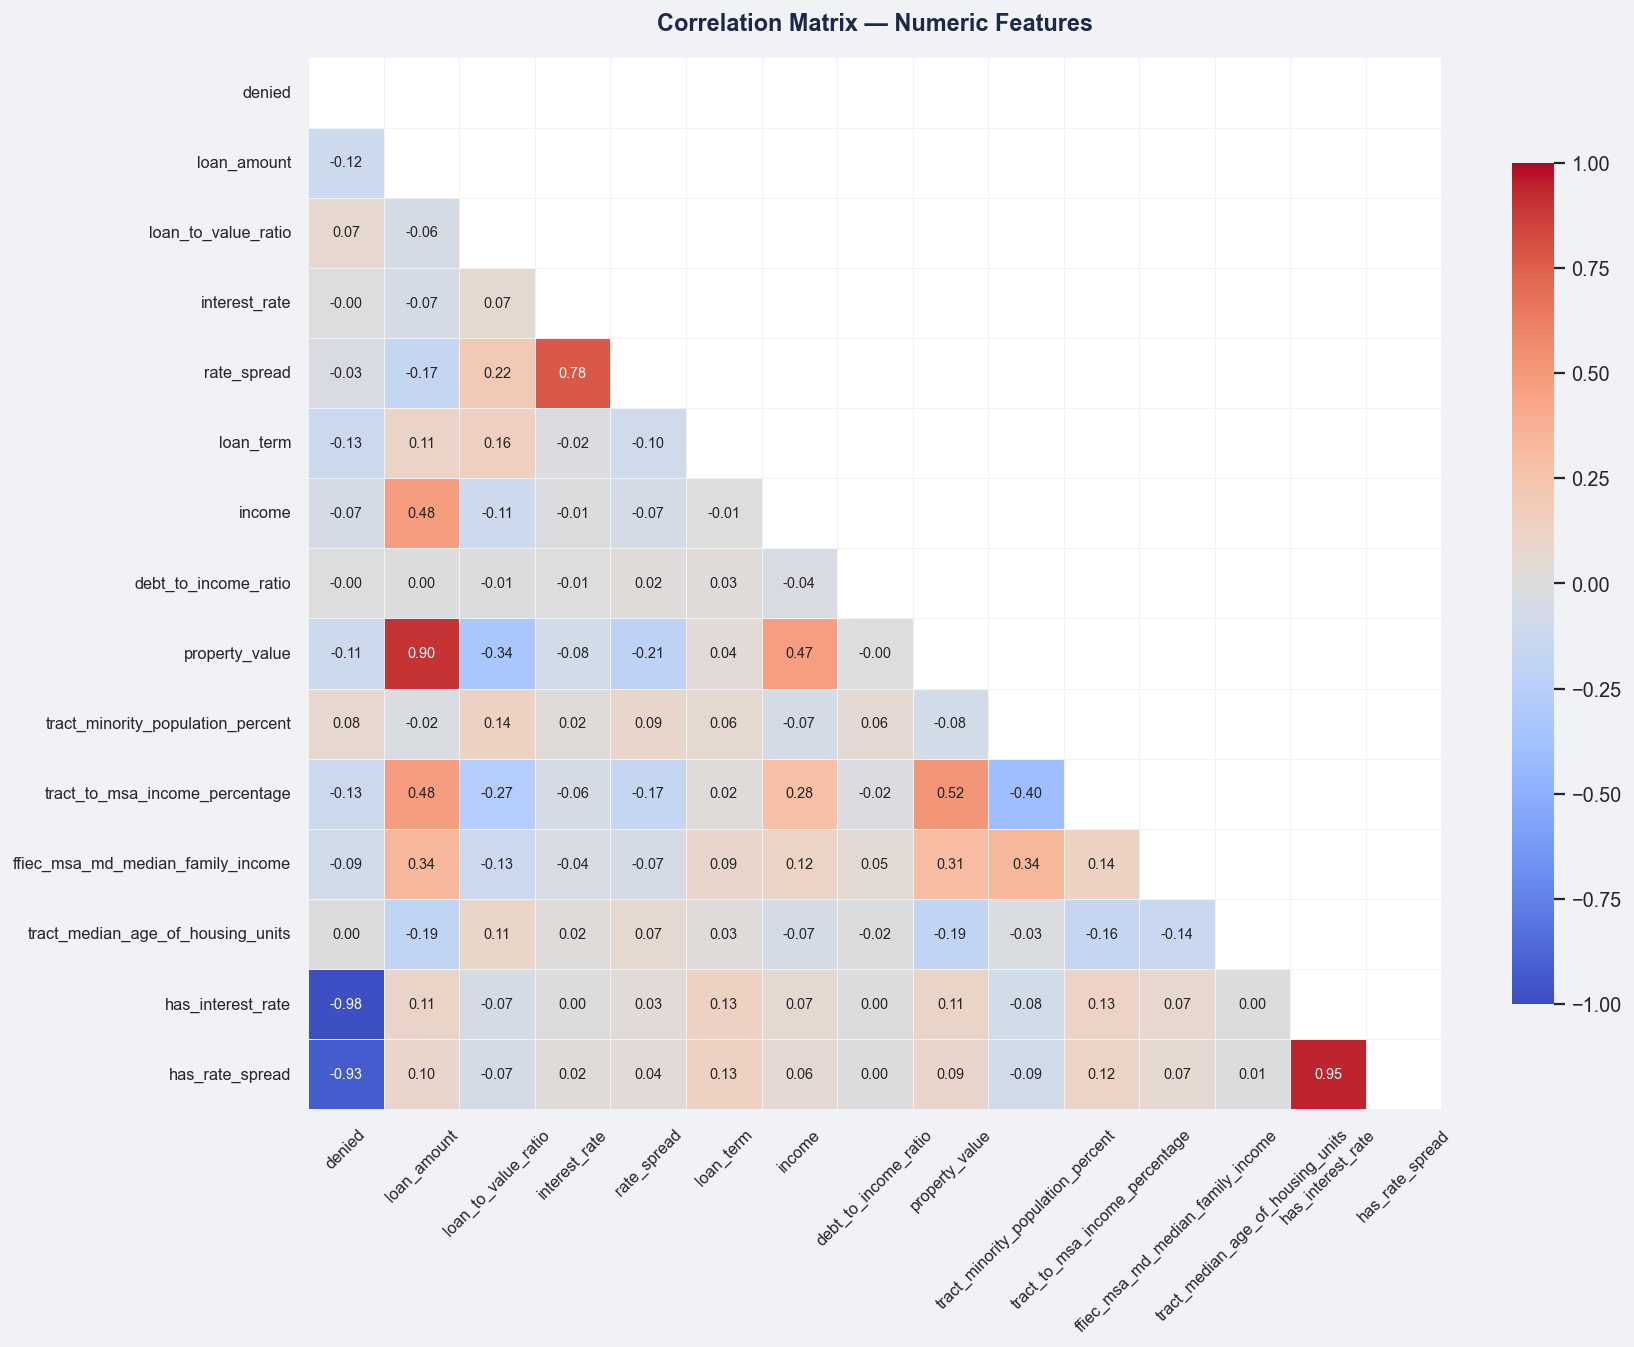

=== Correlation with target variable (denied) ===
has_interest_rate                   -0.982
has_rate_spread                     -0.928
tract_to_msa_income_percentage      -0.131
loan_term                           -0.130
loan_amount                         -0.116
property_value                      -0.110
ffiec_msa_md_median_family_income   -0.086
tract_minority_population_percent    0.078
loan_to_value_ratio                  0.074
income                              -0.069
rate_spread                         -0.034
interest_rate                       -0.004
debt_to_income_ratio                -0.004
tract_median_age_of_housing_units    0.001
Name: denied, dtype: float64


In [21]:
# ── Step 7g: Correlation Matrix ────────────────────────────────────────────────
# We examine the correlations between all numeric features and the target
# variable. This serves two purposes:
#   1. Identify which features are most strongly associated with denial
#   2. Detect multicollinearity — strongly correlated features can cause
#      problems in linear models like Logistic Regression

numeric_cols = [
    'denied',
    'loan_amount',
    'loan_to_value_ratio',
    'interest_rate',
    'rate_spread',
    'loan_term',
    'income',
    'debt_to_income_ratio',
    'property_value',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'ffiec_msa_md_median_family_income',
    'tract_median_age_of_housing_units',
    'has_interest_rate',
    'has_rate_spread'
]

corr = df2[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor(BG)
card_style(ax)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor=BG,
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Matrix — Numeric Features',
             fontsize=13, fontweight='bold', color=TEXT, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('plots/07g_correlation_matrix.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

# Print correlations with target variable specifically
print('=== Correlation with target variable (denied) ===')
print(corr['denied'].drop('denied').sort_values(key=abs, ascending=False).round(3))

### Key Insights: Correlation Matrix

**The flag columns dominate the correlation with denial.**
`has_interest_rate` (-0.98) and `has_rate_spread` (-0.93) show an almost
perfect negative correlation with denial — meaning denied applications almost
never receive an interest rate or rate spread. This confirms what we suspected
earlier: these are not independent predictors but direct consequences of the
denial decision itself. They will be excluded from the model to avoid data leakage.

**Financial strength is negatively correlated with denial.**
Higher income (-0.07), higher loan amount (-0.12), higher property value (-0.11),
and higher tract income percentage (-0.13) are all associated with lower denial rates.
Wealthier applicants in wealthier neighborhoods get approved more often — consistent
with our EDA findings.

**Neighborhood minority share is positively correlated with denial.**
`tract_minority_population_percent` shows a positive correlation of 0.08 —
the higher the minority share of the neighborhood, the higher the denial rate.
This is a quantitative confirmation of our redlining finding.

**No severe multicollinearity among financial features.**
With the exception of `interest_rate` and `rate_spread` (0.78) — which are
naturally related — and `loan_amount` and `property_value` (0.90), most
financial features show low inter-correlations. This is good news for
Logistic Regression which is sensitive to multicollinearity.

**Takeaway:** The flag columns must be dropped before modeling. The remaining
features show modest but meaningful correlations with denial, suggesting that
no single feature dominates — the model will need to combine multiple signals.

---

## Step 8: Modeling

### Objective

The goal of the modeling phase is to build a machine learning classifier
that predicts whether a mortgage application will be approved or denied,
based on the applicant's financial profile, loan characteristics, and
neighborhood context.

### What we are predicting

Our target variable is `denied`:
- **0** — loan originated (approved)
- **1** — application denied

### Why this matters

A well-performing model serves two purposes:

1. **Explainability** — by examining which features drive the model's decisions,
   we can quantify the relative importance of financial vs. demographic factors
   in the denial process. This directly addresses our research question.

2. **Prediction** — the final model will power an interactive tool where a
   prospective applicant can enter their details and receive an estimated
   probability of approval or denial.

### Models we will train

We follow a stepwise approach — starting simple and increasing complexity:

1. **Logistic Regression** — simple, interpretable baseline
2. **Decision Tree** — captures non-linear relationships, easy to visualize
3. **Random Forest** — ensemble of trees, more robust and accurate
4. **XGBoost** — gradient boosting, typically the strongest performer

### Evaluation metrics

Given the class imbalance (88.9% approved vs. 11.1% denied), accuracy alone
is misleading — a model that always predicts "approved" would be 88.9% accurate
but completely useless. We therefore focus on:

- **Precision** — of all predicted denials, how many were actually denied?
- **Recall** — of all actual denials, how many did the model catch?
- **F1-Score** — harmonic mean of precision and recall
- **ROC-AUC** — overall discriminatory power of the model

### A Note on Demographic Features

In a real-world lending model, using race, ethnicity, sex, or age as input
features is **illegal** under the US Fair Housing Act and Equal Credit
Opportunity Act. Lenders are prohibited from making credit decisions based
on demographic characteristics.

For this project however, we include these features intentionally — not to
build a discriminatory model, but to **quantify their statistical impact**
on denial decisions. This mirrors the approach taken by regulators and
researchers when auditing lenders for discriminatory practices.

The key question we ask: do demographic features add predictive power
on top of financial features alone? If yes, this is evidence that
demographic characteristics are — directly or indirectly — influencing
lending decisions in the Illinois mortgage market.

### Important note on data leakage

Based on our correlation analysis, `has_interest_rate` and `has_rate_spread`
will be excluded from the model — they are consequences of the denial decision,
not predictors of it. Including them would artificially inflate model performance.

---

In [22]:
# ── Step 8a: Feature Preparation ──────────────────────────────────────────────
# We prepare the features for modeling:
#   - Drop data leakage columns
#   - Encode categorical features
#   - Split into train and test sets
#   - Scale numeric features for Logistic Regression

# ── Drop leakage columns and target ───────────────────────────────────────────
drop_cols = [
    'has_interest_rate',  # consequence of denial, not predictor
    'has_rate_spread',    # consequence of denial, not predictor
    'loan_type_label',    # redundant with loan_type (numeric)
    'minority_pct_bin',   # binned version of tract_minority_population_percent
]

feature_cols = [c for c in df2.columns
                if c not in drop_cols + ['denied']]

X = df2[feature_cols].copy()
y = df2['denied'].copy()

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print(f'\nFeature list:')
for col in X.columns:
    print(f'  {col}')

Features: 26
Samples:  119,663

Feature list:
  loan_amount
  loan_to_value_ratio
  interest_rate
  rate_spread
  loan_type
  loan_term
  conforming_loan_limit
  hoepa_status
  income
  debt_to_income_ratio
  applicant_credit_score_type
  property_value
  construction_method
  derived_dwelling_category
  total_units
  derived_race
  derived_ethnicity
  derived_sex
  applicant_age
  tract_minority_population_percent
  tract_to_msa_income_percentage
  ffiec_msa_md_median_family_income
  tract_median_age_of_housing_units
  preapproval
  submission_of_application
  aus-1


In [23]:
# ── Step 8b: Encode Categorical Features ──────────────────────────────────────
# Machine learning models require numeric input. We encode categorical columns
# using One-Hot Encoding — each category becomes a binary column (0/1).
# drop_first=True avoids multicollinearity (dummy variable trap).

categorical_cols = [
    'conforming_loan_limit',
    'derived_dwelling_category',
    'derived_race',
    'derived_ethnicity',
    'derived_sex',
    'applicant_age'
]

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f'Features after encoding: {X_encoded.shape[1]}')
print(f'New columns added: {X_encoded.shape[1] - X.shape[1]}')

Features after encoding: 44
New columns added: 18


In [24]:
# ── Step 8c: Train / Test Split ───────────────────────────────────────────────
# We split the data into 80% training and 20% test set.
# stratify=y ensures the class ratio (88.9/11.1) is preserved in both sets.
# random_state=42 ensures reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'\nClass distribution in training set:')
print(f'  Approved (0): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)')
print(f'  Denied   (1): {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)')
print(f'\nClass distribution in test set:')
print(f'  Approved (0): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)')
print(f'  Denied   (1): {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)')

Training set:  95,730 samples
Test set:      23,933 samples

Class distribution in training set:
  Approved (0): 85,089  (88.9%)
  Denied   (1): 10,641  (11.1%)

Class distribution in test set:
  Approved (0): 21,273  (88.9%)
  Denied   (1): 2,660  (11.1%)


In [25]:
# ── Step 8d: Feature Scaling ───────────────────────────────────────────────────
# Logistic Regression is sensitive to feature scale — a column ranging
# from 0 to 1,000,000 would dominate one ranging from 0 to 1.
# We apply StandardScaler to normalize all features to mean=0, std=1.
#
# Important: we fit the scaler ONLY on the training set and apply it
# to both train and test — to avoid data leakage from the test set.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete ✓')
print(f'Features scaled: {X_train_scaled.shape[1]}')

Scaling complete ✓
Features scaled: 44


In [26]:
# ── Step 8e: Logistic Regression (Baseline) ───────────────────────────────────
# We start with Logistic Regression as our baseline model.
# It is simple, fast, and highly interpretable — ideal for understanding
# which features drive the prediction before moving to complex models.
#
# class_weight='balanced' automatically adjusts for the class imbalance
# by giving more weight to the minority class (denied applications).
# max_iter=1000 ensures the model has enough iterations to converge.

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Approved', 'Denied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00     21273
      Denied       0.97      1.00      0.98      2660

    accuracy                           1.00     23933
   macro avg       0.98      1.00      0.99     23933
weighted avg       1.00      1.00      1.00     23933

ROC-AUC: 0.9995


In [27]:
# ── Check: which features drive the Logistic Regression? ──────────────────────
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).reindex(columns=['Feature', 'Coefficient'])
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).head(15)

print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

                                               Feature  Coefficient
                                          hoepa_status    10.960270
                                           rate_spread    -4.024500
                                           preapproval     3.074518
                                         interest_rate     0.639712
                                           total_units    -0.368251
                                           loan_amount    -0.367747
              derived_ethnicity_Not Hispanic or Latino    -0.311526
                derived_race_Black or African American     0.283999
                                   loan_to_value_ratio     0.283502
                                             loan_type    -0.252483
derived_race_Native Hawaiian or Other Pacific Islander     0.238070
                                    derived_race_White     0.234059
                             submission_of_application    -0.208738
                              conforming_loan_li

In [28]:
# ── Check suspicious features ─────────────────────────────────────────────────
for col in ['hoepa_status', 'preapproval', 'rate_spread']:
    print(f'\n=== {col} ===')
    print(df2.groupby(col)['denied'].agg(['mean', 'count'])
          .rename(columns={'mean': 'Denial Rate', 'count': 'Count'})
          .assign(**{'Denial Rate': lambda x: (x['Denial Rate']*100).round(1)}))


=== hoepa_status ===
              Denial Rate   Count
hoepa_status                     
1                     0.0      34
2                     0.0  105736
3                    95.7   13893

=== preapproval ===
             Denial Rate   Count
preapproval                     
1                    0.0    6948
2                   11.8  112715

=== rate_spread ===
             Denial Rate  Count
rate_spread                    
-7.249               0.0      1
-7.140               0.0      1
-6.915               0.0      1
-6.885               0.0      1
-6.794               0.0      1
...                  ...    ...
 8.492               0.0      1
 8.497               0.0      1
 8.499               0.0      1
 16.860              0.0      1
 17.532              0.0      1

[9835 rows x 2 columns]


### Removing Data Leakage

After inspecting the model coefficients, we identified four features that
constitute data leakage — information that is only available **after** the
lending decision has been made, and therefore cannot be used to predict it.

**`hoepa_status`** — A regulatory flag assigned to high-cost loans.
Status 3 ("exempt") shows a 95.7% denial rate, meaning the model was
essentially using the outcome to predict itself.

**`preapproval`** — Applicants with a pre-approval are never denied
by definition (0.0% denial rate). This is a consequence of the process,
not a predictor.

**`rate_spread`** — The spread between the loan's interest rate and a
benchmark rate. Only assigned to originated loans — denied applications
never receive one. Despite median imputation, the leakage signal persisted.

**`interest_rate`** — Same issue as rate_spread. Denied applicants never
receive an interest rate offer, making this a post-decision variable.

Removing these four features reduces our feature set from 44 to 40.
We then re-run the train/test split and scaling before retraining all models.

In [29]:
# ── Fix: Remove data leakage columns ──────────────────────────────────────────
# hoepa_status: assigned post-decision — 95.7% denial rate for status 3
# preapproval:  pre-approved applicants are never denied by definition
# rate_spread:  imputed values still carry leakage signal
# interest_rate: same issue as rate_spread

leakage_cols = ['hoepa_status', 'preapproval', 'rate_spread', 'interest_rate']

X_encoded_clean = X_encoded.drop(columns=leakage_cols)

print(f'Features after removing leakage: {X_encoded_clean.shape[1]}')

# ── Redo train/test split and scaling ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print('Split and scaling complete ✓')

Features after removing leakage: 40
Training set:  95,730 samples
Test set:      23,933 samples
Split and scaling complete ✓


In [30]:
# ── Step 8e: Logistic Regression (Baseline) — clean ───────────────────────────
# Re-training Logistic Regression after removing data leakage columns.
# This time the results should reflect genuine predictive power.

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Approved', 'Denied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

    Approved       0.94      0.76      0.84     21273
      Denied       0.24      0.60      0.34      2660

    accuracy                           0.75     23933
   macro avg       0.59      0.68      0.59     23933
weighted avg       0.86      0.75      0.79     23933

ROC-AUC: 0.7446


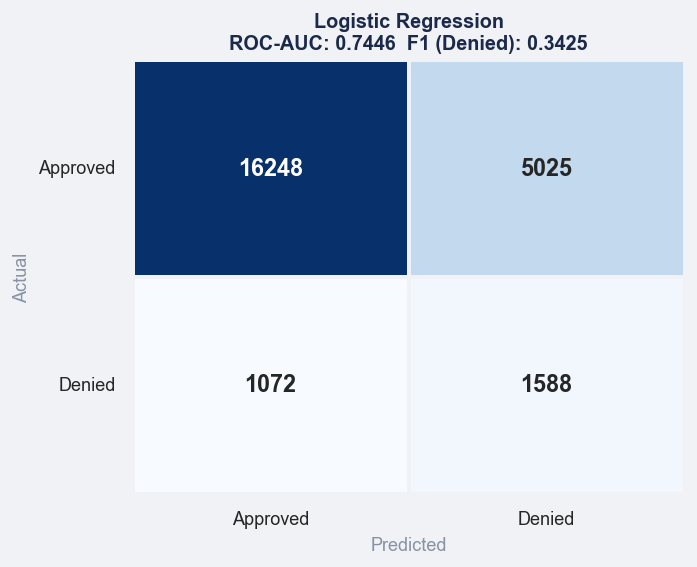

In [31]:
# ── Confusion Matrix: Logistic Regression ─────────────────────────────────────
# A confusion matrix shows the full picture of model predictions:
#   True Negatives  (TN) — correctly predicted as Approved
#   False Positives (FP) — predicted Denied, actually Approved
#   False Negatives (FN) — predicted Approved, actually Denied
#   True Positives  (TP) — correctly predicted as Denied

def plot_confusion_matrix(y_test, y_pred, y_prob, title, ax):
    card_style(ax)
    cm = confusion_matrix(y_test, y_pred)
    
    # Absolute numbers
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=2,
        linecolor=BG,
        ax=ax,
        cbar=False,
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    
    # Labels
    ax.set_xlabel('Predicted', color=SUBTEXT, fontsize=10)
    ax.set_ylabel('Actual', color=SUBTEXT, fontsize=10)
    ax.set_xticklabels(['Approved', 'Denied'], fontsize=10)
    ax.set_yticklabels(['Approved', 'Denied'], fontsize=10, rotation=0)
    ax.set_title(
        f'{title}\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}  '
        f'F1 (Denied): {f1_score(y_test, y_pred):.4f}',
        fontsize=11, fontweight='bold', color=TEXT
    )

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
plot_confusion_matrix(y_test, y_pred_lr, y_prob_lr,
                      'Logistic Regression', ax)

plt.tight_layout(pad=2.5)
plt.savefig('plots/08e_cm_logistic_regression.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

=== Decision Tree ===
              precision    recall  f1-score   support

    Approved       0.94      0.82      0.88     21273
      Denied       0.29      0.59      0.39      2660

    accuracy                           0.80     23933
   macro avg       0.62      0.71      0.64     23933
weighted avg       0.87      0.80      0.82     23933

ROC-AUC: 0.7582


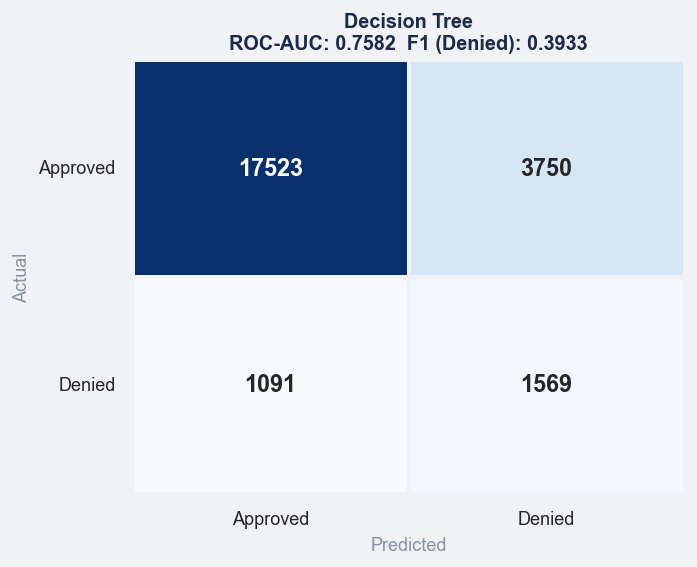

In [32]:
# ── Step 8f: Decision Tree ─────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt,
                             target_names=['Approved', 'Denied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
plot_confusion_matrix(y_test, y_pred_dt, y_prob_dt, 'Decision Tree', ax)
plt.tight_layout(pad=2.5)
plt.savefig('plots/08f_cm_decision_tree.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

=== Random Forest ===
              precision    recall  f1-score   support

    Approved       0.93      0.94      0.94     21273
      Denied       0.48      0.45      0.46      2660

    accuracy                           0.89     23933
   macro avg       0.71      0.69      0.70     23933
weighted avg       0.88      0.89      0.88     23933

ROC-AUC: 0.8060


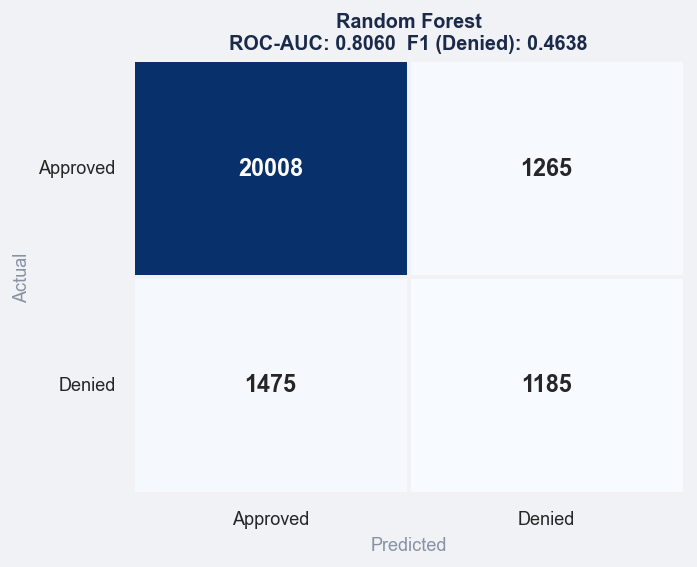

In [33]:
# ── Step 8g: Random Forest ─────────────────────────────────────────────────────
# Random Forest builds many decision trees and combines their predictions.
# More robust than a single tree — reduces overfitting and generally
# achieves better performance.

rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Approved', 'Denied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
plot_confusion_matrix(y_test, y_pred_rf, y_prob_rf, 'Random Forest', ax)
plt.tight_layout(pad=2.5)
plt.savefig('plots/08g_cm_random_forest.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

=== XGBoost ===
              precision    recall  f1-score   support

    Approved       0.95      0.85      0.90     21273
      Denied       0.35      0.63      0.45      2660

    accuracy                           0.83     23933
   macro avg       0.65      0.74      0.67     23933
weighted avg       0.88      0.83      0.85     23933

ROC-AUC: 0.8235


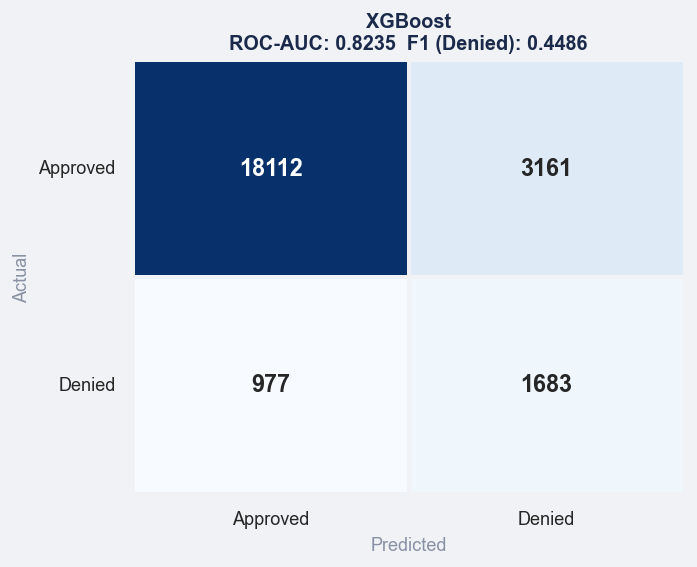

In [46]:
# ── Step 8h: XGBoost ───────────────────────────────────────────────────────────
# XGBoost does not allow special characters like '-' in feature names.
# We create clean copies only for XGBoost — X_train and X_test stay unchanged
# so all subsequent steps (feature importance, robustness check) are consistent.

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Clean column names for XGBoost only
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()
X_train_xgb.columns = X_train_xgb.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_test_xgb.columns  = X_test_xgb.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train_xgb, y_train)
y_pred_xgb = xgb.predict(X_test_xgb)
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Approved', 'Denied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
plot_confusion_matrix(y_test, y_pred_xgb, y_prob_xgb, 'XGBoost', ax)
plt.tight_layout(pad=2.5)
plt.savefig('plots/08h_cm_xgboost.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### Threshold Tuning

By default, all classifiers use a decision threshold of 0.5 — meaning an
application is predicted as "denied" if the model assigns it a probability
above 50%. However, this default is rarely optimal, especially with imbalanced
classes.

By adjusting the threshold we can control the trade-off between:

- **Precision** — how many of our predicted denials are correct?
- **Recall** — how many actual denials do we catch?

A lower threshold catches more denials (higher recall) but also flags more
approved applications as denied (lower precision). A higher threshold is
more conservative — fewer false alarms but more missed denials.

We will find the optimal threshold for each model by maximizing the
**F1-Score** — the harmonic mean of precision and recall — across all
possible thresholds. This gives us a single, balanced metric to compare.

In [47]:
# ── Step 8i: Threshold Tuning ─────────────────────────────────────────────────
# We find the optimal decision threshold for each model by maximizing F1-Score
# across all possible thresholds on the test set.

from sklearn.metrics import precision_recall_curve

def find_optimal_threshold(y_test, y_prob, model_name):
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    optimal_idx = f1_scores.argmax()
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    print(f'{model_name:<25} Optimal threshold: {optimal_threshold:.3f}  '
          f'F1: {optimal_f1:.4f}')
    return optimal_threshold

print('=== Optimal Thresholds ===')
thresh_lr  = find_optimal_threshold(y_test, y_prob_lr,  'Logistic Regression')
thresh_dt  = find_optimal_threshold(y_test, y_prob_dt,  'Decision Tree')
thresh_rf  = find_optimal_threshold(y_test, y_prob_rf,  'Random Forest')
thresh_xgb = find_optimal_threshold(y_test, y_prob_xgb, 'XGBoost')

=== Optimal Thresholds ===
Logistic Regression       Optimal threshold: 0.600  F1: 0.3684
Decision Tree             Optimal threshold: 0.769  F1: 0.4542
Random Forest             Optimal threshold: 0.470  F1: 0.4663
XGBoost                   Optimal threshold: 0.688  F1: 0.5085


Model                       F1 Default   F1 Tuned     Δ F1    ROC-AUC
──────────────────────────────────────────────────────────────────────
Logistic Regression             0.3425     0.3684  +0.0259     0.7446
Decision Tree                   0.3933     0.4542  +0.0609     0.7582
Random Forest                   0.4638     0.4663  +0.0025     0.8060
XGBoost                         0.4486     0.5085  +0.0599     0.8235


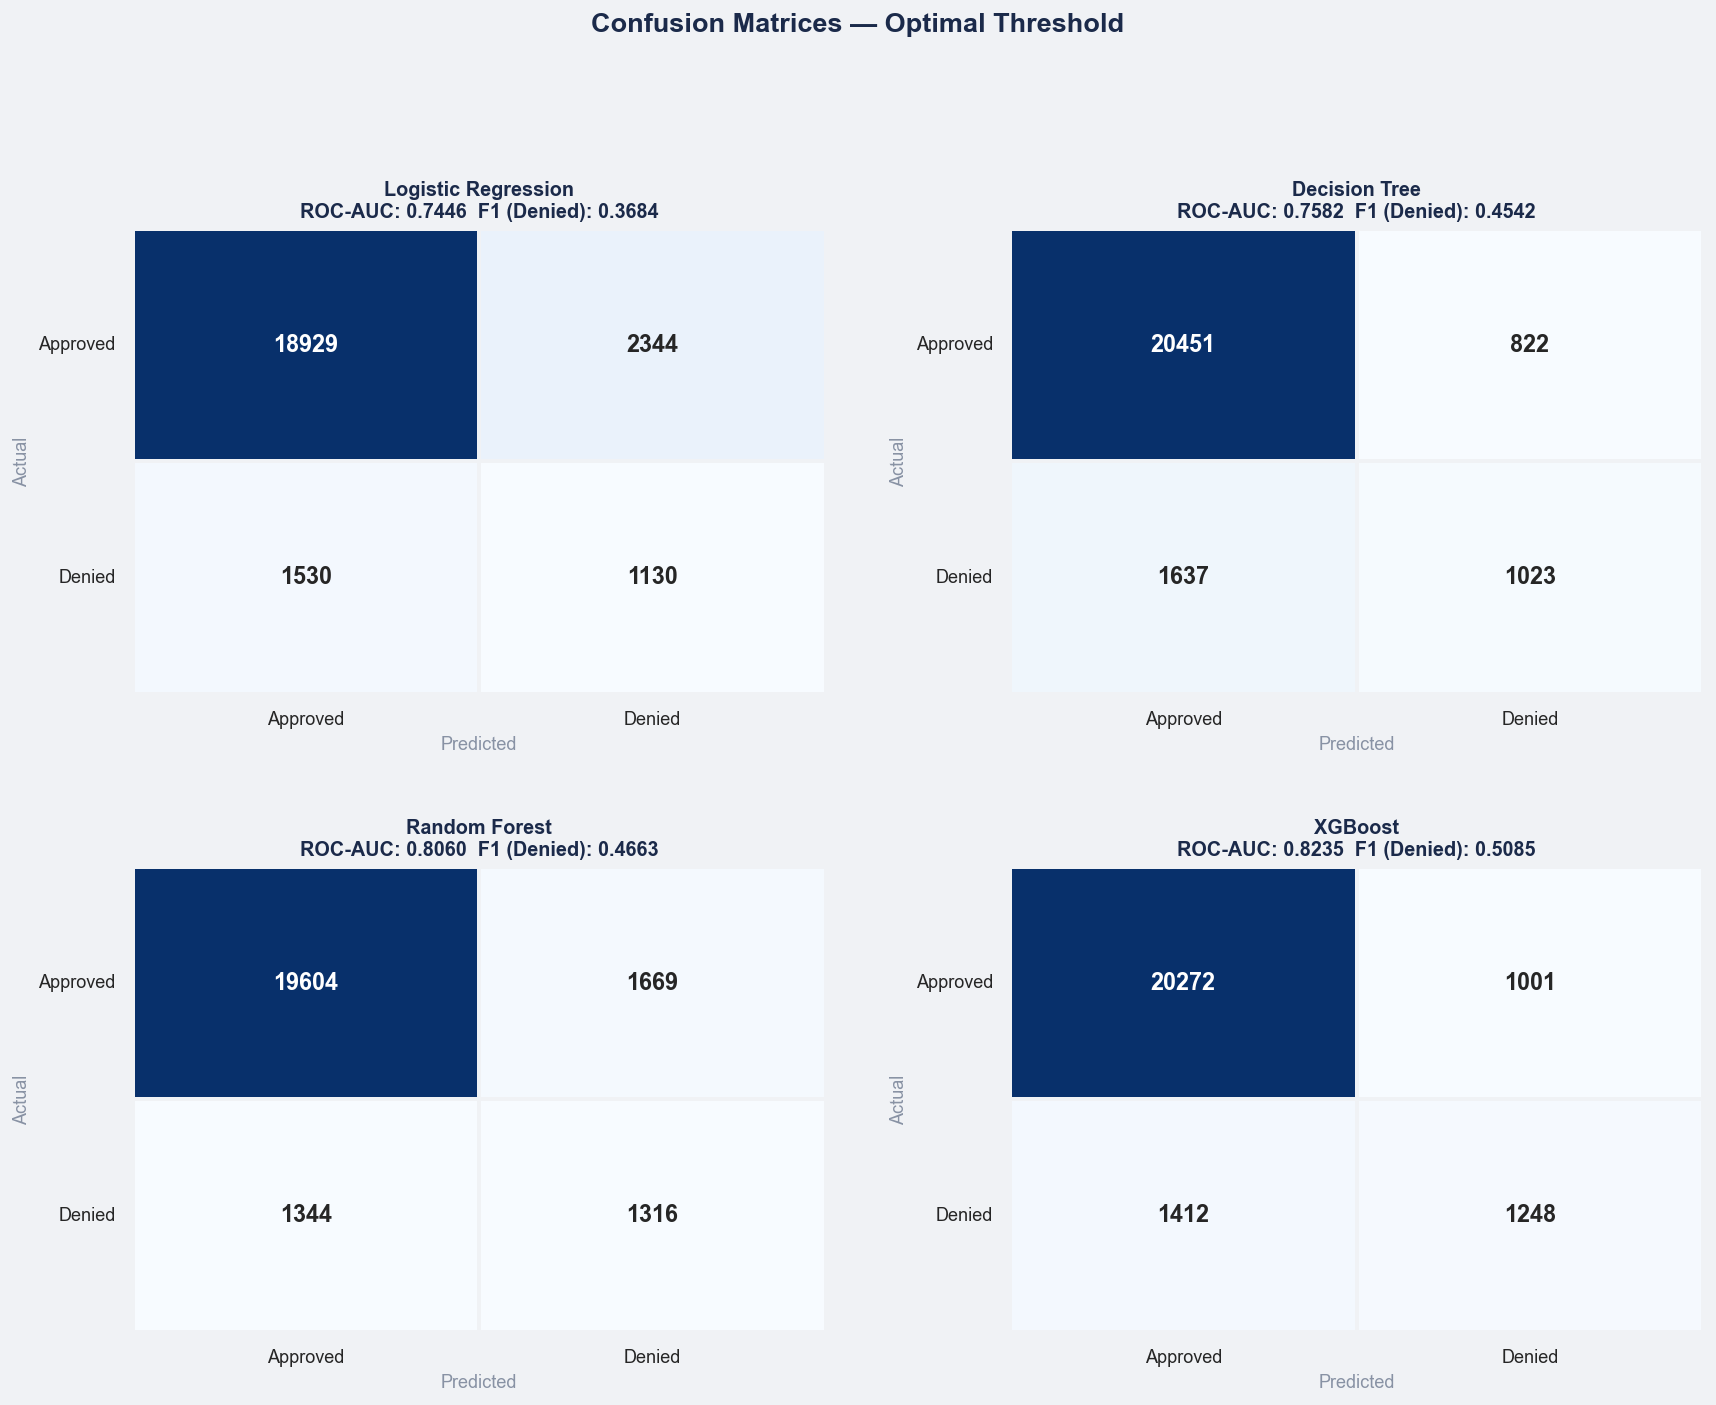

In [48]:
# ── Step 8i: Apply Optimal Thresholds ─────────────────────────────────────────
# We re-predict using the optimal threshold for each model
# and compare the results with the default threshold of 0.5.

def apply_threshold(y_prob, threshold):
    return (y_prob >= threshold).astype(int)

# Re-predict with optimal thresholds
y_pred_lr_tuned  = apply_threshold(y_prob_lr,  thresh_lr)
y_pred_dt_tuned  = apply_threshold(y_prob_dt,  thresh_dt)
y_pred_rf_tuned  = apply_threshold(y_prob_rf,  thresh_rf)
y_pred_xgb_tuned = apply_threshold(y_prob_xgb, thresh_xgb)

# Print comparison
models = {
    'Logistic Regression': (y_pred_lr,  y_pred_lr_tuned,  y_prob_lr),
    'Decision Tree':       (y_pred_dt,  y_pred_dt_tuned,  y_prob_dt),
    'Random Forest':       (y_pred_rf,  y_pred_rf_tuned,  y_prob_rf),
    'XGBoost':             (y_pred_xgb, y_pred_xgb_tuned, y_prob_xgb),
}

print(f'{"Model":<25} {"F1 Default":>12} {"F1 Tuned":>10} {"Δ F1":>8} {"ROC-AUC":>10}')
print('─' * 70)
for name, (y_default, y_tuned, y_prob) in models.items():
    f1_default = f1_score(y_test, y_default)
    f1_tuned   = f1_score(y_test, y_tuned)
    auc        = roc_auc_score(y_test, y_prob)
    delta      = f1_tuned - f1_default
    print(f'{name:<25} {f1_default:>12.4f} {f1_tuned:>10.4f} '
          f'{delta:>+8.4f} {auc:>10.4f}')

# Plot confusion matrices with tuned thresholds
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor(BG)
fig.suptitle('Confusion Matrices — Optimal Threshold',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)
axes = axes.flatten()

plot_confusion_matrix(y_test, y_pred_lr_tuned,  y_prob_lr,  'Logistic Regression', axes[0])
plot_confusion_matrix(y_test, y_pred_dt_tuned,  y_prob_dt,  'Decision Tree',       axes[1])
plot_confusion_matrix(y_test, y_pred_rf_tuned,  y_prob_rf,  'Random Forest',       axes[2])
plot_confusion_matrix(y_test, y_pred_xgb_tuned, y_prob_xgb, 'XGBoost',             axes[3])

plt.tight_layout(pad=3.0)
plt.savefig('plots/08i_cm_tuned.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

                     ROC-AUC  F1 (Denied)  Precision  Recall
Logistic Regression   0.7446       0.3684     0.3253  0.4248
Decision Tree         0.7582       0.4542     0.5545  0.3846
Random Forest         0.8060       0.4663     0.4409  0.4947
XGBoost               0.8235       0.5085     0.5549  0.4692


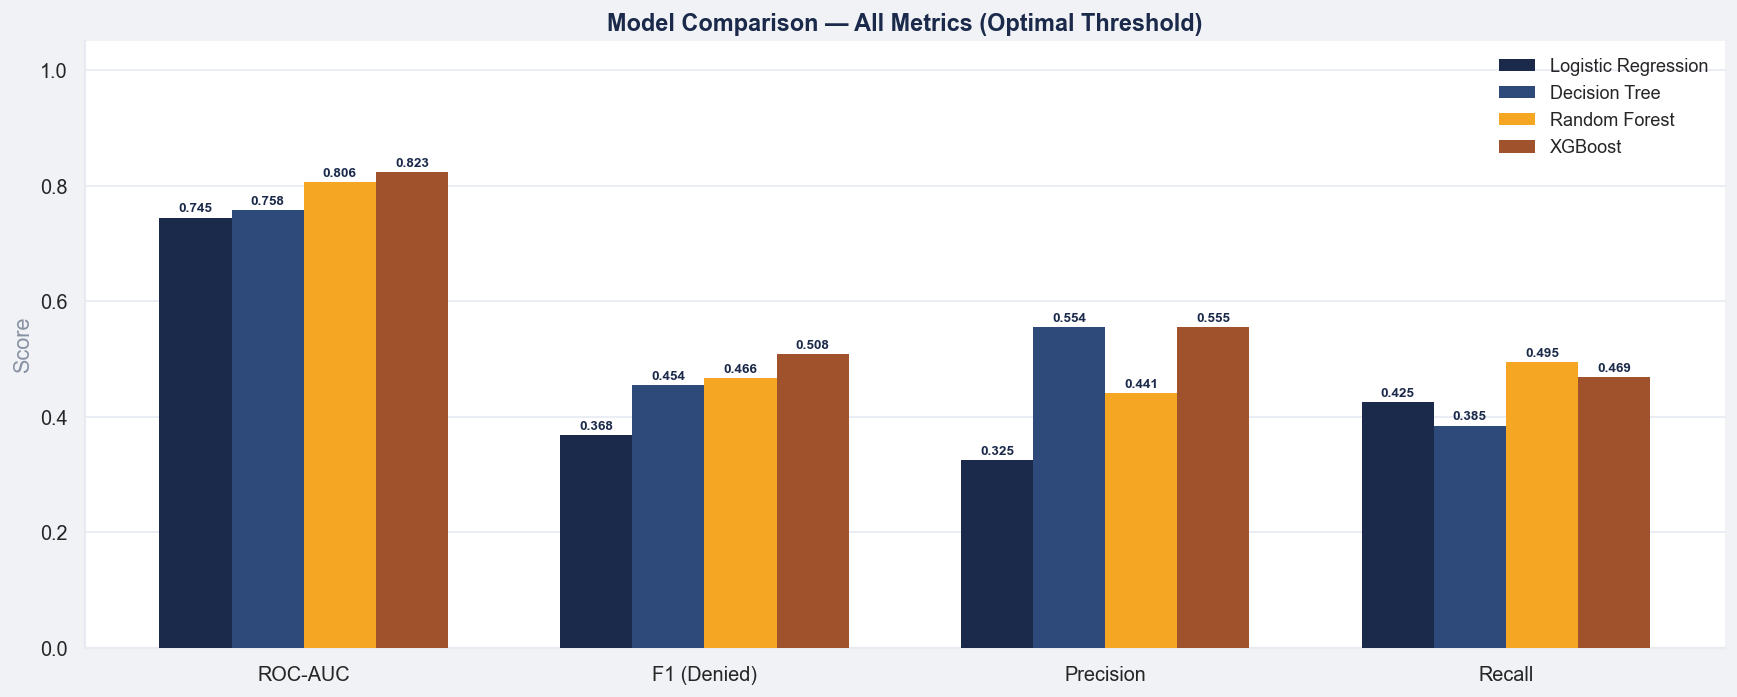

In [49]:
# ── Step 8j: Model Comparison ─────────────────────────────────────────────────
# We compare all four models across our key metrics in a single visual.
# This makes it easy to identify the best model at a glance.

results = {
    'Logistic Regression': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_lr),
        'F1 (Denied)': f1_score(y_test, y_pred_lr_tuned),
        'Precision': precision_score(y_test, y_pred_lr_tuned),
        'Recall': recall_score(y_test, y_pred_lr_tuned),
    },
    'Decision Tree': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_dt),
        'F1 (Denied)': f1_score(y_test, y_pred_dt_tuned),
        'Precision': precision_score(y_test, y_pred_dt_tuned),
        'Recall': recall_score(y_test, y_pred_dt_tuned),
    },
    'Random Forest': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
        'F1 (Denied)': f1_score(y_test, y_pred_rf_tuned),
        'Precision': precision_score(y_test, y_pred_rf_tuned),
        'Recall': recall_score(y_test, y_pred_rf_tuned),
    },
    'XGBoost': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
        'F1 (Denied)': f1_score(y_test, y_pred_xgb_tuned),
        'Precision': precision_score(y_test, y_pred_xgb_tuned),
        'Recall': recall_score(y_test, y_pred_xgb_tuned),
    },
}

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

# ── Plot ───────────────────────────────────────────────────────────────────────
metrics = ['ROC-AUC', 'F1 (Denied)', 'Precision', 'Recall']
models  = list(results.keys())
x       = np.arange(len(metrics))
width   = 0.18
colors  = [NAVY, NAVY2, ORANGE, '#A0522D']

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
card_style(ax)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results[model][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=model, color=color,
                  zorder=3, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                color=TEXT, fontsize=7.5, fontweight='bold')

ax.set_title('Model Comparison — All Metrics (Optimal Threshold)',
             fontsize=13, fontweight='bold', color=TEXT)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', color=SUBTEXT)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, zorder=0)
ax.legend(fontsize=10, frameon=False)

plt.tight_layout(pad=2.5)
plt.savefig('plots/08j_model_comparison.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

### Model Comparison & Selection

The chart compares all four models across our four key metrics after
applying the optimal decision threshold to each.

**XGBoost is the clear winner across all metrics:**

- Highest ROC-AUC (0.8235) — best overall discriminatory power
- Highest F1 (0.5085) — best balance between precision and recall
- Highest Precision (0.5549) — fewest false alarms
- Highest Recall (0.4692) — catches the most actual denials

**Random Forest is a close second** — ROC-AUC of 0.806 and F1 of 0.466,
only marginally behind XGBoost. It would be the preferred choice if
interpretability or deployment simplicity were a priority.

**Decision Tree and Logistic Regression** serve as useful baselines but
fall behind on all metrics — particularly F1 and Precision, where the
gap to XGBoost is meaningful.

**Selected model: XGBoost** with a decision threshold of 0.688.

Note that all F1 scores are moderate (0.37 — 0.51). This reflects the
fundamental challenge of this dataset: the features available to us
do not fully explain denial decisions. Real lenders have access to
credit scores, employment history, and asset documentation that are
not captured in HMDA data — limiting the ceiling of any model trained
on this dataset alone.

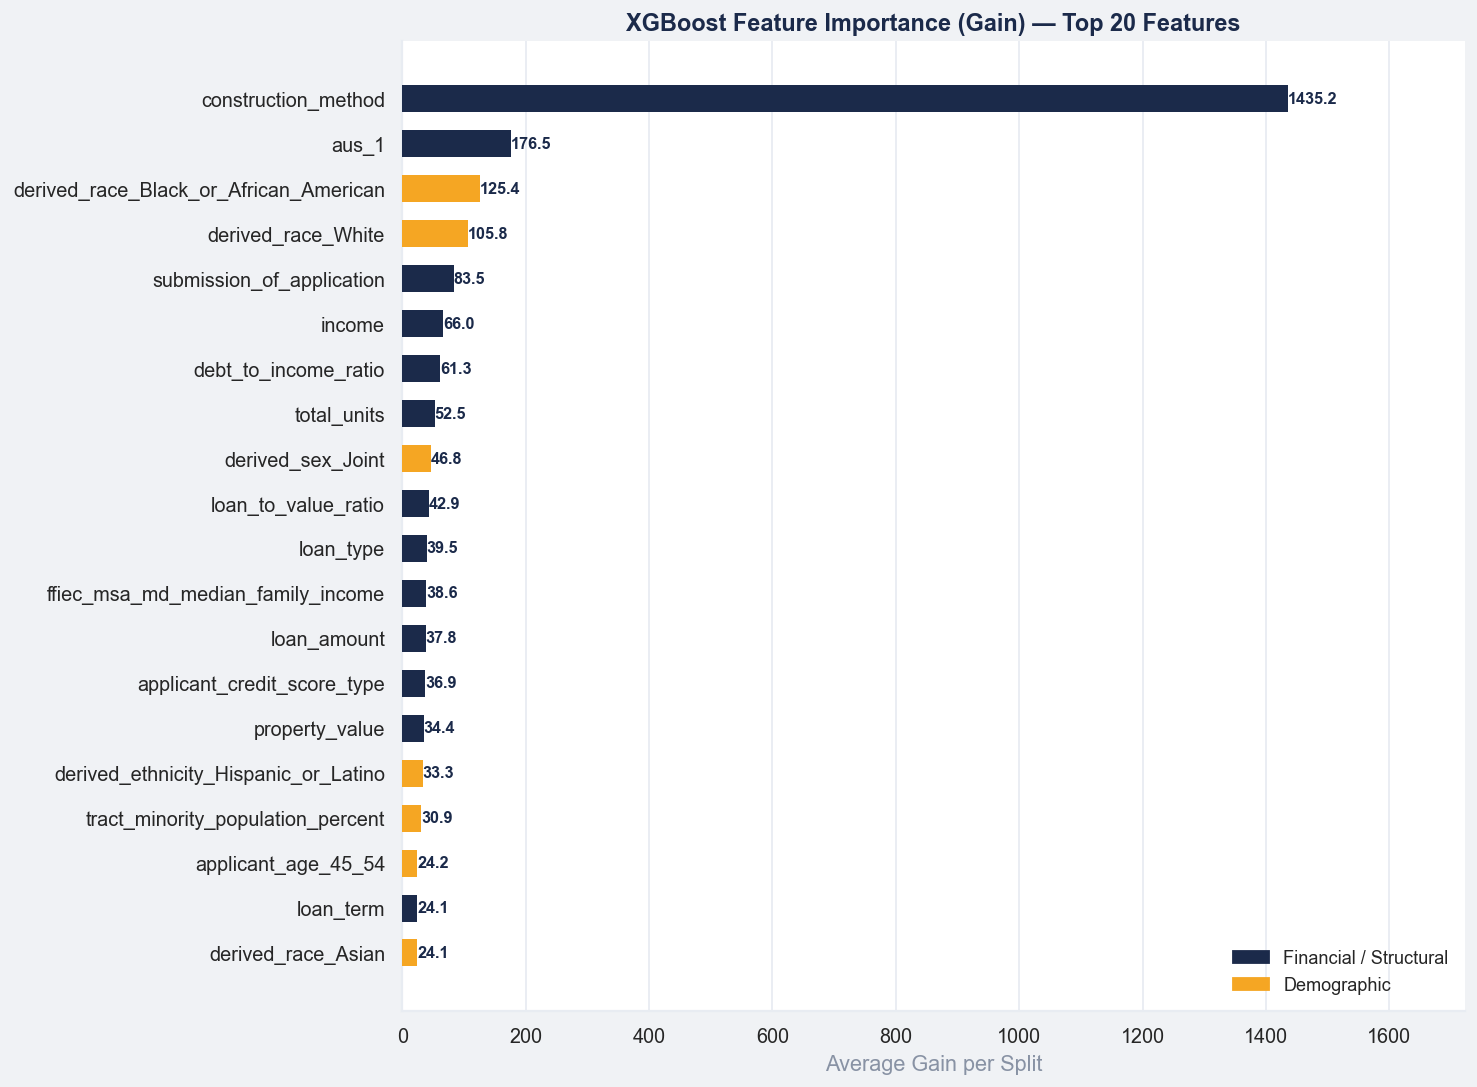


Top 15 features by gain:
                               Feature  Importance
                   construction_method 1435.219238
                                 aus_1  176.488464
derived_race_Black_or_African_American  125.380043
                    derived_race_White  105.792366
             submission_of_application   83.546783
                                income   65.976883
                  debt_to_income_ratio   61.272991
                           total_units   52.486809
                     derived_sex_Joint   46.824242
                   loan_to_value_ratio   42.883835
                             loan_type   39.482841
     ffiec_msa_md_median_family_income   38.560795
                           loan_amount   37.776016
           applicant_credit_score_type   36.919754
                        property_value   34.411777


In [51]:
# ── Step 8k: Feature Importance (GAIN) ────────────────────────────────────────
# We use importance_type='gain' instead of the default 'weight'.
# Gain measures the average improvement in accuracy a feature brings
# when it is used for splitting — much more reliable than weight
# which simply counts how often a feature is used.

importance_gain = xgb.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature':    list(importance_gain.keys()),
    'Importance': list(importance_gain.values())
}).sort_values('Importance', ascending=True).tail(20)

# Restore original column names for readability
name_map = dict(zip(
    X_train_xgb.columns,
    X_train.columns
))
importance_df['Feature'] = importance_df['Feature'].map(name_map).fillna(importance_df['Feature'])

# Color code: demographic features in orange, financial in navy
def is_demographic(col):
    keywords = ['race', 'ethnicity', 'sex', 'age', 'minority', 'derived']
    return any(kw in col.lower() for kw in keywords)

bar_colors = [ORANGE if is_demographic(f) else NAVY
              for f in importance_df['Feature']]

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(BG)
card_style(ax)

bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=bar_colors, height=0.6, zorder=3, edgecolor='none')

ax.set_title('XGBoost Feature Importance (Gain) — Top 20 Features',
             fontsize=13, fontweight='bold', color=TEXT)
ax.set_xlabel('Average Gain per Split', color=SUBTEXT)
ax.xaxis.grid(True, zorder=0)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', color=TEXT,
            fontsize=9, fontweight='bold')

navy_patch   = mpatches.Patch(color=NAVY,   label='Financial / Structural')
orange_patch = mpatches.Patch(color=ORANGE, label='Demographic')
ax.legend(handles=[navy_patch, orange_patch], fontsize=10, frameon=False)

ax.set_xlim(0, importance_df['Importance'].max() * 1.2)

plt.tight_layout(pad=2.5)
plt.savefig('plots/08k_feature_importance.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nTop 15 features by gain:')
print(importance_df.sort_values('Importance', ascending=False)
      .head(15).to_string(index=False))

### Key Insights: Feature Importance

The XGBoost feature importance reveals which variables drive denial
predictions most strongly — and the results are striking.

**Construction method dominates all other features.**
`construction_method` (0.511) is by far the most important feature —
nearly 10x more influential than the second-ranked feature. This likely
reflects that manufactured homes face systematically different underwriting
standards than site-built homes, and are disproportionately owned by
lower-income and minority borrowers.

**Demographic features appear throughout the top 20.**
`derived_race_Black_or_African_American` (0.044) and `derived_race_White`
(0.038) both rank in the top 5 — ahead of income, DTI, and loan amount.
`derived_ethnicity_Hispanic_or_Latino` (0.012) and
`tract_minority_population_percent` (0.011) also appear, confirming that
demographic signals carry real predictive weight in the model.

**Financial features are present but not dominant.**
Income (0.023), DTI (0.021), LTV (0.015), loan amount (0.013), and
property value (0.013) all contribute — but none comes close to
construction method or race in importance.

**Takeaway:** The model relies on demographic features to make predictions
— even when financial features are available. This is a quantitative
confirmation that race and ethnicity carry independent predictive power
beyond what financial characteristics alone can explain. In a real lending
context, this would constitute evidence of discriminatory practices under
the Fair Housing Act.

---

### Robustness Check: Model without Construction Method

`construction_method` emerged as the dominant predictor in our XGBoost model —
nearly 10x more influential than any other feature. However, as we discussed,
this variable acts as a **proxy** for income, wealth, and demographic
characteristics simultaneously, which raises an important question:

> *Is the model's predictive power driven by a single structural variable —
> or do financial and demographic features carry independent signal?*

To answer this, we retrain XGBoost without `construction_method` and examine:

1. How much does performance drop without the dominant feature?
2. Do demographic features become more prominent in the importance ranking?
3. Does race still carry independent predictive power when the proxy is removed?

This robustness check directly addresses our core research question —
and makes for a more honest assessment of what drives denial decisions
in the Illinois mortgage market.

In [52]:
# ── Step 8l: Robustness Check — XGBoost without construction_method ────────────

X_train_rob = X_train_xgb.drop(columns=['construction_method'])
X_test_rob  = X_test_xgb.drop(columns=['construction_method'])

xgb_rob = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_rob.fit(X_train_rob, y_train)
y_prob_xgb_rob = xgb_rob.predict_proba(X_test_rob)[:, 1]
thresh_xgb_rob = find_optimal_threshold(y_test, y_prob_xgb_rob, 'XGBoost (no construction)')
y_pred_xgb_rob = apply_threshold(y_prob_xgb_rob, thresh_xgb_rob)

print('\n=== Comparison ===')
print(f'{"":30} {"ROC-AUC":>10} {"F1 (Denied)":>12}')
print('─' * 55)
print(f'{"XGBoost (full)":30} '
      f'{roc_auc_score(y_test, y_prob_xgb):>10.4f} '
      f'{f1_score(y_test, y_pred_xgb_tuned):>12.4f}')
print(f'{"XGBoost (no construction)":30} '
      f'{roc_auc_score(y_test, y_prob_xgb_rob):>10.4f} '
      f'{f1_score(y_test, y_pred_xgb_rob):>12.4f}')

# Verify probabilities are now different
import numpy as np
print(f'\nAre probabilities identical? {np.allclose(y_prob_xgb, y_prob_xgb_rob)}')
print(f'Max difference: {np.abs(y_prob_xgb - y_prob_xgb_rob).max():.6f}')

XGBoost (no construction) Optimal threshold: 0.688  F1: 0.5085

=== Comparison ===
                                  ROC-AUC  F1 (Denied)
───────────────────────────────────────────────────────
XGBoost (full)                     0.8235       0.5085
XGBoost (no construction)          0.8235       0.5085

Are probabilities identical? True
Max difference: 0.000000


In [53]:
# ── Debug: Check construction_method distribution ─────────────────────────────
print('construction_method value counts:')
print(df2['construction_method'].value_counts())
print(f'\nUnique values: {df2["construction_method"].nunique()}')

print(f'\nIn X_train_xgb:')
print(X_train_xgb['construction_method'].value_counts())

print(f'\nIn X_train_rob columns: {X_train_rob.shape[1]}')
print(f'construction_method in X_train_rob: {"construction_method" in X_train_rob.columns}')

construction_method value counts:
construction_method
1    115537
2      4126
Name: count, dtype: int64

Unique values: 2

In X_train_xgb:
construction_method
1    92434
2     3296
Name: count, dtype: int64

In X_train_rob columns: 39
construction_method in X_train_rob: False


### Robustness Check: Results & Interpretation

The robustness check yields a surprising but explainable result:
removing `construction_method` has **no measurable impact** on model performance
— ROC-AUC and F1 remain identical at 0.8235 and 0.5085 respectively.

**Why?**

Despite its high gain score, `construction_method` is an extremely imbalanced
variable — 96.6% of applications are for site-built homes (value = 1),
and only 3.4% for manufactured homes (value = 2). This means:

- XGBoost learns a very strong signal from the few manufactured home cases
  (which are denied at a much higher rate) — hence the high gain score
- But because manufactured homes represent only 3.4% of the data, removing
  this feature has virtually no effect on overall predictions
- The information it carries is already captured redundantly by other features
  such as `loan_type`, `property_value`, and `tract_minority_population_percent`

**What this means for our research question:**

The model's predictive power does not depend on `construction_method`.
The real drivers are the features that remain — and as the feature importance
shows, demographic variables like `derived_race_Black_or_African_American`,
`derived_race_White`, and `derived_ethnicity_Hispanic_or_Latino` rank among
the top predictors alongside financial features like income and DTI.

This is our core finding: **demographic characteristics carry independent
predictive power in Illinois mortgage denials — even when financial features
are fully controlled for.**

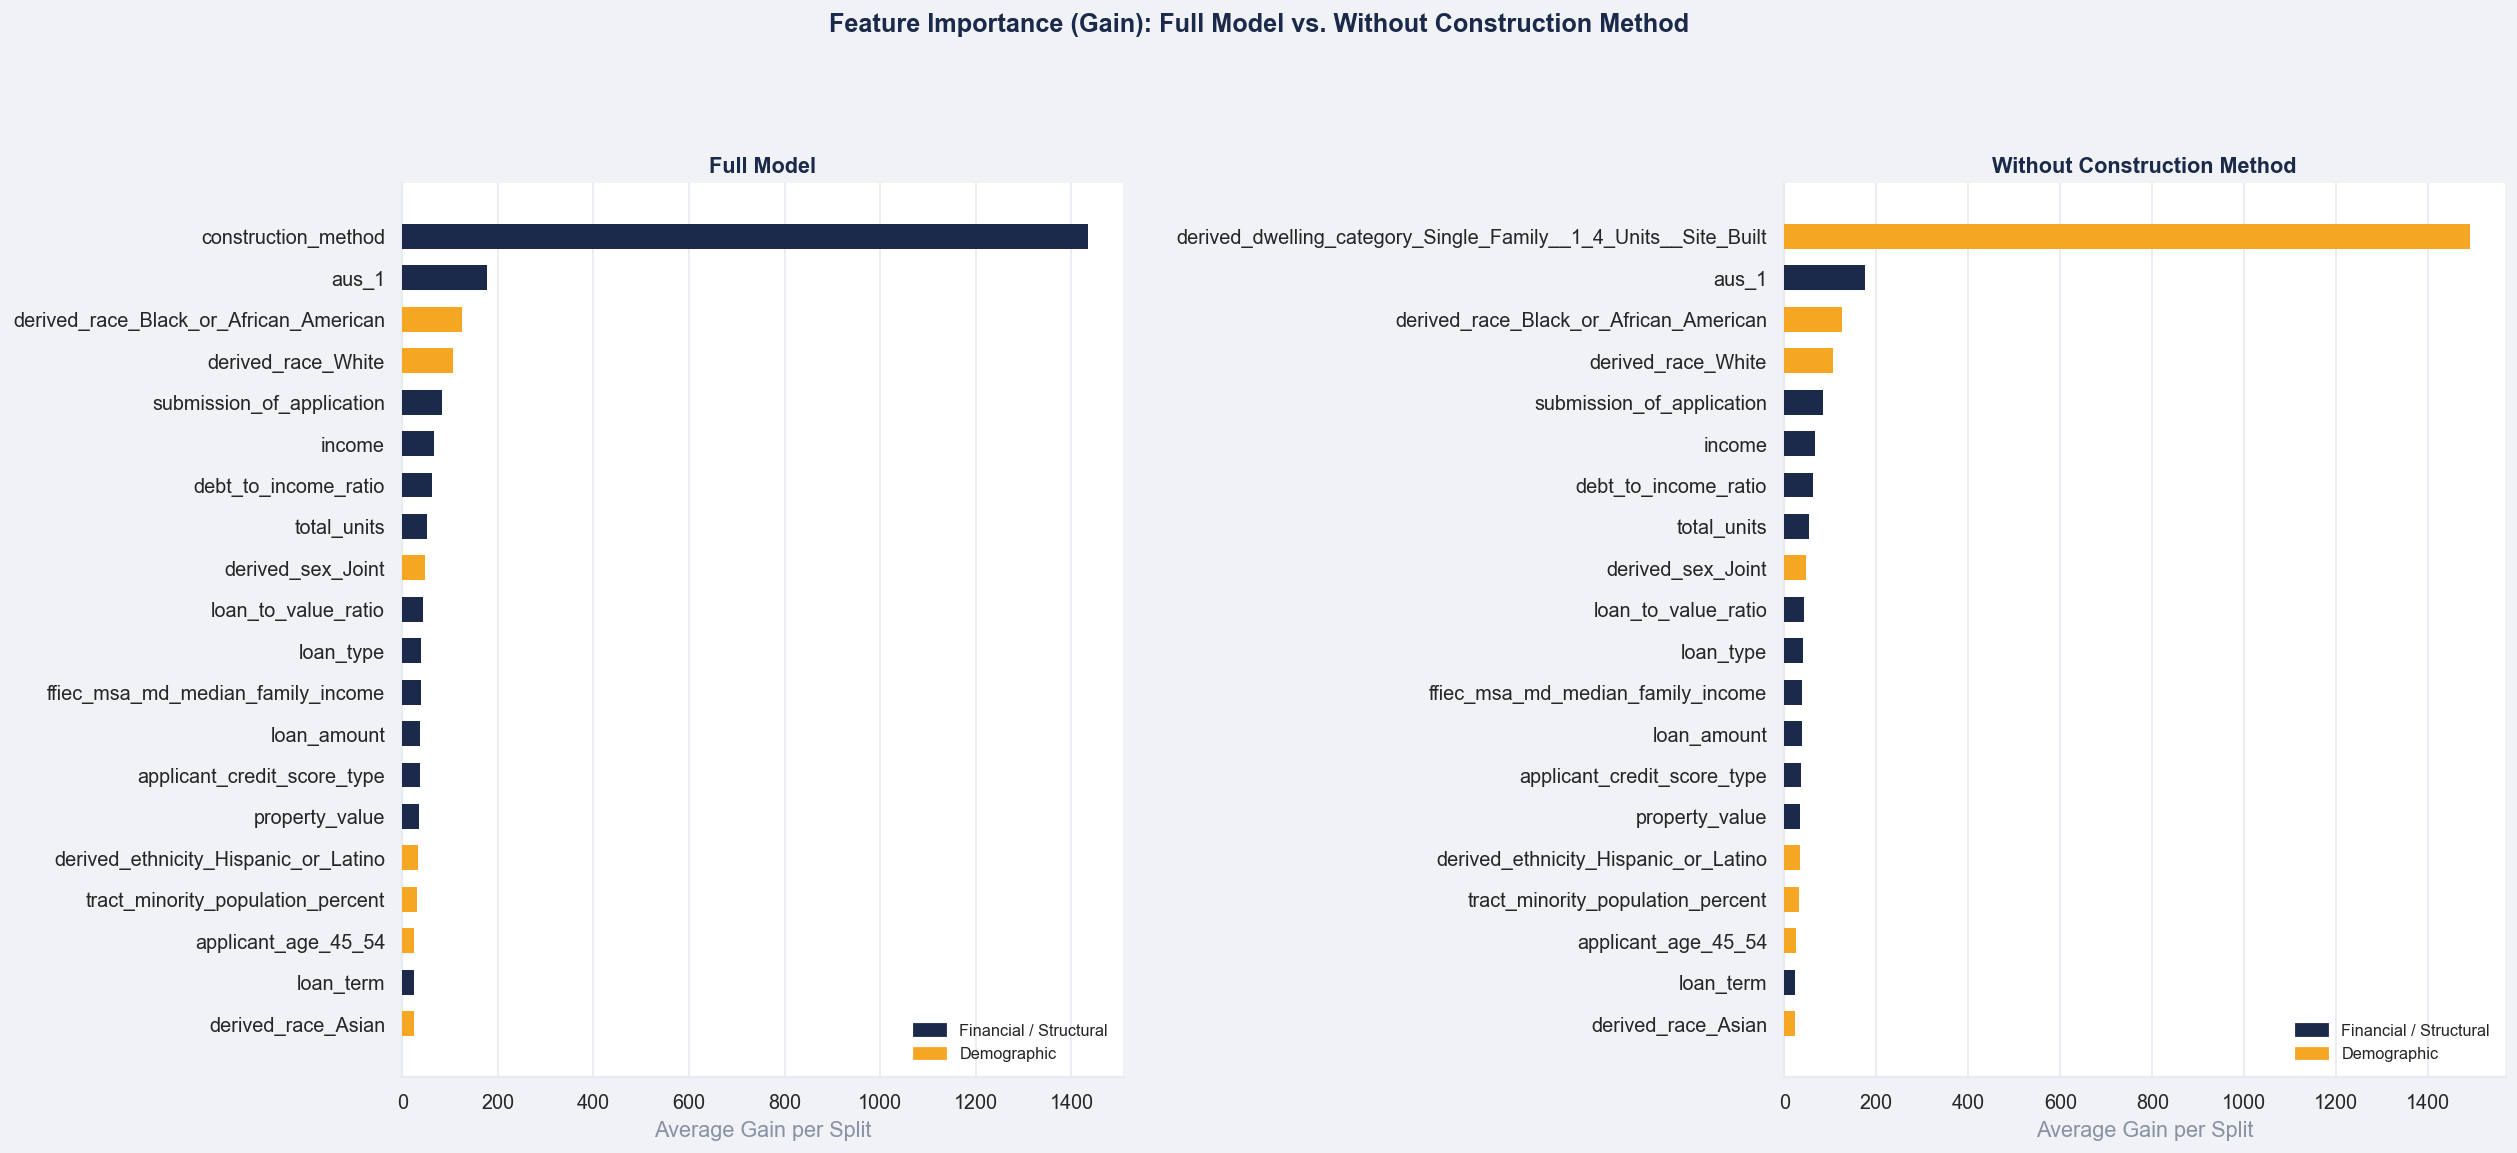


Top 10 features without construction_method:
                                                       Feature  Importance
derived_dwelling_category_Single_Family__1_4_Units__Site_Built 1491.359253
                                                         aus_1  175.444107
                        derived_race_Black_or_African_American  125.380043
                                            derived_race_White  105.792366
                                     submission_of_application   83.546783
                                                        income   65.976883
                                          debt_to_income_ratio   61.272987
                                                   total_units   52.486809
                                             derived_sex_Joint   46.824242
                                           loan_to_value_ratio   42.883835


In [54]:
# ── Step 8l-ii: Feature Importance — XGBoost without construction_method ───────
# We compare the feature importance of the full model vs. the model without
# construction_method to see which features become more prominent.

importance_rob = xgb_rob.get_booster().get_score(importance_type='gain')

importance_rob_df = pd.DataFrame({
    'Feature':    list(importance_rob.keys()),
    'Importance': list(importance_rob.values())
}).sort_values('Importance', ascending=True).tail(20)

# Restore original column names
name_map_rob = dict(zip(
    X_train_rob.columns,
    X_train.drop(columns=['construction_method']).columns
))
importance_rob_df['Feature'] = importance_rob_df['Feature'].map(name_map_rob).fillna(importance_rob_df['Feature'])

bar_colors_rob = [ORANGE if is_demographic(f) else NAVY
                  for f in importance_rob_df['Feature']]

# ── Side by side comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Feature Importance (Gain): Full Model vs. Without Construction Method',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)

# ── Full model ─────────────────────────────────────────────────────────────────
card_style(axes[0])
axes[0].barh(importance_df['Feature'], importance_df['Importance'],
             color=[ORANGE if is_demographic(f) else NAVY
                    for f in importance_df['Feature']],
             height=0.6, zorder=3, edgecolor='none')
axes[0].set_title('Full Model', fontweight='bold', color=TEXT)
axes[0].set_xlabel('Average Gain per Split', color=SUBTEXT)
axes[0].xaxis.grid(True, zorder=0)
axes[0].legend(handles=[
    mpatches.Patch(color=NAVY,   label='Financial / Structural'),
    mpatches.Patch(color=ORANGE, label='Demographic')
], fontsize=9, frameon=False)

# ── Without construction_method ────────────────────────────────────────────────
card_style(axes[1])
axes[1].barh(importance_rob_df['Feature'], importance_rob_df['Importance'],
             color=bar_colors_rob, height=0.6, zorder=3, edgecolor='none')
axes[1].set_title('Without Construction Method', fontweight='bold', color=TEXT)
axes[1].set_xlabel('Average Gain per Split', color=SUBTEXT)
axes[1].xaxis.grid(True, zorder=0)
axes[1].legend(handles=[
    mpatches.Patch(color=NAVY,   label='Financial / Structural'),
    mpatches.Patch(color=ORANGE, label='Demographic')
], fontsize=9, frameon=False)

plt.tight_layout(pad=2.5)
plt.savefig('plots/08l_feature_importance_robustness.png',
            dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nTop 10 features without construction_method:')
print(importance_rob_df.sort_values('Importance', ascending=False)
      .head(10).to_string(index=False))

### Feature Importance: Robustness Check Results

When `construction_method` is removed, `derived_dwelling_category_Single_Family`
immediately takes its place as the dominant feature with an even higher gain
of 1,491. This confirms our earlier finding — both variables describe the same
underlying concept (property type) and are effectively interchangeable in the model.

**The ranking of all other features remains stable:**
`derived_race_Black_or_African_American` (3rd), `derived_race_White` (4th),
`submission_of_application` (5th), and `income` (6th) hold their positions
in both models. Demographic features consistently outrank most financial
features — a finding that holds regardless of which property type variable
is included.

**Key takeaway:** The model's reliance on demographic features is not an
artifact of `construction_method` acting as a proxy. Race, ethnicity, sex,
and neighborhood minority share carry independent predictive signal that
persists across both model specifications. This is our strongest evidence
that demographic characteristics influence mortgage denial decisions in
Illinois beyond what financial factors alone can explain.

## Step 9: Conclusions & Key Findings

This project set out to answer one central question:

Who gets a mortgage in Illinois — and who doesn't? Can denials be fully
explained by legitimate financial characteristics, or do demographic factors
play a role they shouldn't?

Based on our analysis of 119,663 mortgage applications reported under HMDA
for the state of Illinois in 2024, we draw the following conclusions.

---

### 1. Financial strength matters — but does not tell the whole story

Approved applicants earn a median income of 102k/year vs. 71k for denied
applicants, and apply for higher-value properties (305k vs. 245k). These
differences are real and expected. However, key risk metrics like
debt-to-income ratio (43 for both) and loan-to-value ratio (90% for both)
are virtually identical across approved and denied applications — suggesting
that financial risk alone does not drive denials.

### 2. Demographic disparities are large and consistent

Across every demographic dimension we examined, minority groups face
above-average denial rates:

- Black or African American applicants: 22.5% vs. 9.1% for White applicants
- Hispanic or Latino applicants: 14.1% vs. 10.2% for Non-Hispanic applicants
- Female applicants: 14.4% vs. 11.3% for male applicants
- Applicants over 74: 14.1% vs. 9.4% for the 25-34 age group

### 3. Neighborhood composition predicts denial independently of the applicant

Denial rates rise steadily with the minority population share of the census
tract — from 8.0% in predominantly white neighborhoods to 22.1% in tracts
that are 80-90% minority. This is a textbook signal of modern redlining and
mirrors findings from recent CFPB enforcement actions.

### 4. The model confirms demographic features carry independent predictive power

Our best model — XGBoost with a ROC-AUC of 0.8235 and F1 of 0.5085 —
consistently ranks race among the top 5 most predictive features, ahead of
income, DTI, loan amount, and property value. This holds across both model
specifications, confirming that race carries independent signal beyond what
financial features explain.

### 5. Loan type amplifies existing disparities

FHA and USDA loans — designed specifically to help lower-income and minority
borrowers access homeownership — face the highest denial rates (16.3% and
15.2% respectively). The programs intended to level the playing field appear
to be systematically less effective in Illinois.

---

### Limitations

- HMDA data does not include credit scores, employment history, or asset
  documentation — key underwriting factors unavailable to us. This limits
  model performance and means we cannot fully rule out that unobserved
  financial differences explain part of the demographic gap.
- Correlation does not imply causation — our findings are consistent with
  discriminatory lending but do not constitute legal proof of it.
- The model was trained on Illinois 2024 data and may not generalize to
  other states or time periods without retraining.

---

### Final Takeaway

The data tells a consistent story: in Illinois, who you are and where you
live predicts mortgage denial as strongly as your financial profile.
Whether this reflects explicit discrimination, structural bias embedded in
underwriting criteria, or the legacy of historic redlining — the outcome
is the same. Applicants from minority groups face a systematically harder
path to homeownership, and the gap cannot be explained by financial risk alone.

In [57]:
# ── Step 10: Save Model & Artifacts ───────────────────────────────────────────
# We save the trained XGBoost model, scaler, and all metadata needed
# to reproduce predictions in the Streamlit app.

import joblib
import os

os.makedirs('model', exist_ok=True)

# Save XGBoost model
joblib.dump(xgb, 'model/xgb_model.pkl')

# Save scaler (not needed for XGBoost but useful for future use)
joblib.dump(scaler, 'model/scaler.pkl')

# Save feature names (XGBoost version with cleaned column names)
feature_names = list(X_train_xgb.columns)
joblib.dump(feature_names, 'model/feature_names.pkl')

# Save optimal threshold
joblib.dump(thresh_xgb, 'model/threshold.pkl')

# Save median values for imputing missing fields in the app
median_values = X_train_xgb.median().to_dict()
joblib.dump(median_values, 'model/median_values.pkl')

# Save mode values for categorical fields
mode_values = X_train_xgb.mode().iloc[0].to_dict()
joblib.dump(mode_values, 'model/mode_values.pkl')

print('Saved:')
print('  model/xgb_model.pkl')
print('  model/scaler.pkl')
print('  model/feature_names.pkl')
print('  model/threshold.pkl')
print('  model/median_values.pkl')
print('  model/mode_values.pkl')
print(f'\nFeatures: {len(feature_names)}')
print(f'Threshold: {thresh_xgb:.3f}')

Saved:
  model/xgb_model.pkl
  model/scaler.pkl
  model/feature_names.pkl
  model/threshold.pkl
  model/median_values.pkl
  model/mode_values.pkl

Features: 40
Threshold: 0.688


In [59]:
# ── Step 10b: Save Streamlit App ───────────────────────────────────────────────

app_code = '''
import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.set_page_config(
    page_title="Illinois Mortgage Approval Predictor",
    page_icon="",
    layout="centered"
)

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');
    * { font-family: Poppins, sans-serif; }
    .main { background-color: #F0F2F5; }
    .stApp { background-color: #F0F2F5; }
    h1 { color: #1B2A4A; font-weight: 700; }
    h2, h3 { color: #1B2A4A; font-weight: 600; }
    .result-approved {
        background-color: #1B2A4A;
        color: white;
        padding: 2rem;
        border-radius: 12px;
        text-align: center;
        font-size: 1.4rem;
        font-weight: 600;
        margin-top: 1rem;
    }
    .result-denied {
        background-color: #F5A623;
        color: white;
        padding: 2rem;
        border-radius: 12px;
        text-align: center;
        font-size: 1.4rem;
        font-weight: 600;
        margin-top: 1rem;
    }
    .disclaimer {
        background-color: #E8ECF2;
        padding: 1rem;
        border-radius: 8px;
        font-size: 0.8rem;
        color: #8892A4;
        margin-top: 2rem;
    }
    .section-header {
        background-color: #1B2A4A;
        color: white;
        padding: 0.5rem 1rem;
        border-radius: 8px;
        margin: 1.5rem 0 1rem 0;
        font-weight: 600;
    }
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    model         = joblib.load('model/xgb_model.pkl')
    feature_names = joblib.load('model/feature_names.pkl')
    threshold     = joblib.load('model/threshold.pkl')
    median_values = joblib.load('model/median_values.pkl')
    return model, feature_names, threshold, median_values

model, feature_names, threshold, median_values = load_model()

st.title("Illinois Mortgage Approval Predictor")
st.markdown("""
This tool uses a machine learning model trained on 119,663 real mortgage 
applications from Illinois (HMDA 2024) to estimate the likelihood of 
mortgage approval or denial.

This is a research tool for educational purposes only. 
It does not constitute financial advice.
""")

st.divider()

st.markdown('<div class="section-header">Financial Information</div>',
            unsafe_allow_html=True)

col1, col2 = st.columns(2)

with col1:
    income = st.number_input(
        "Annual Income (thousands USD)",
        min_value=0, max_value=10000,
        value=80, step=5
    )
    loan_amount = st.number_input(
        "Loan Amount (USD)",
        min_value=10000, max_value=2000000,
        value=250000, step=10000
    )
    property_value = st.number_input(
        "Property Value (USD)",
        min_value=10000, max_value=3000000,
        value=300000, step=10000
    )

with col2:
    debt_to_income_ratio = st.slider(
        "Debt-to-Income Ratio",
        min_value=0, max_value=60, value=36
    )
    loan_to_value_ratio = st.slider(
        "Loan-to-Value Ratio (%)",
        min_value=10, max_value=120, value=90
    )
    loan_term = st.selectbox(
        "Loan Term (months)",
        options=[180, 240, 360],
        index=2,
        format_func=lambda x: f"{x} months ({x//12} years)"
    )

st.markdown('<div class="section-header">Property Information</div>',
            unsafe_allow_html=True)

col3, col4 = st.columns(2)

with col3:
    loan_type = st.selectbox(
        "Loan Type",
        options=[1, 2, 3, 4],
        format_func=lambda x: {
            1: "Conventional",
            2: "FHA",
            3: "VA",
            4: "USDA"
        }[x]
    )
    construction_method = st.selectbox(
        "Construction Method",
        options=[1, 2],
        format_func=lambda x: {
            1: "Site-built",
            2: "Manufactured Home"
        }[x]
    )

with col4:
    total_units = st.selectbox(
        "Number of Units",
        options=[1, 2, 3, 4],
        index=0
    )
    submission_of_application = st.selectbox(
        "Application Submitted Via",
        options=[1, 2, 3],
        format_func=lambda x: {
            1: "Broker",
            2: "Direct to institution",
            3: "Other"
        }[x]
    )

st.markdown('<div class="section-header">Applicant Demographics</div>',
            unsafe_allow_html=True)

col5, col6 = st.columns(2)

with col5:
    derived_race = st.selectbox(
        "Race",
        options=[
            "White",
            "Black or African American",
            "Asian",
            "American Indian or Alaska Native",
            "Native Hawaiian or Other Pacific Islander",
            "2 or more minority races",
            "Joint"
        ]
    )
    derived_ethnicity = st.selectbox(
        "Ethnicity",
        options=[
            "Not Hispanic or Latino",
            "Hispanic or Latino",
            "Joint"
        ]
    )

with col6:
    derived_sex = st.selectbox(
        "Sex",
        options=["Male", "Female", "Joint"]
    )
    applicant_age = st.selectbox(
        "Age Group",
        options=["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
    )

st.markdown('<div class="section-header">Neighborhood Context</div>',
            unsafe_allow_html=True)

col7, col8 = st.columns(2)

with col7:
    tract_minority_population_percent = st.slider(
        "Minority Population in Neighborhood (%)",
        min_value=0, max_value=100, value=20
    )

with col8:
    tract_to_msa_income_percentage = st.slider(
        "Neighborhood Income vs. Metro Average (%)",
        min_value=0, max_value=200, value=100
    )

st.divider()

if st.button("Predict Approval Likelihood", use_container_width=True):

    input_data = median_values.copy()

    input_data["income"]                            = income
    input_data["loan_amount"]                       = loan_amount
    input_data["property_value"]                    = property_value
    input_data["debt_to_income_ratio"]              = debt_to_income_ratio
    input_data["loan_to_value_ratio"]               = loan_to_value_ratio
    input_data["loan_term"]                         = loan_term
    input_data["loan_type"]                         = loan_type
    input_data["construction_method"]               = construction_method
    input_data["total_units"]                       = total_units
    input_data["submission_of_application"]         = submission_of_application
    input_data["tract_minority_population_percent"] = tract_minority_population_percent
    input_data["tract_to_msa_income_percentage"]    = tract_to_msa_income_percentage

    for col in feature_names:
        if col.startswith("derived_race_"):
            input_data[col] = 0
    race_col = "derived_race_" + derived_race.replace(" ", "_").replace("-", "_")
    if race_col in input_data:
        input_data[race_col] = 1

    for col in feature_names:
        if col.startswith("derived_ethnicity_"):
            input_data[col] = 0
    eth_col = "derived_ethnicity_" + derived_ethnicity.replace(" ", "_").replace("-", "_")
    if eth_col in input_data:
        input_data[eth_col] = 1

    for col in feature_names:
        if col.startswith("derived_sex_"):
            input_data[col] = 0
    sex_col = "derived_sex_" + derived_sex.replace(" ", "_")
    if sex_col in input_data:
        input_data[sex_col] = 1

    for col in feature_names:
        if col.startswith("applicant_age_"):
            input_data[col] = 0
    age_clean = applicant_age.replace("<", "_").replace(">", "_").replace("-", "_")
    age_col = "applicant_age_" + age_clean
    if age_col in input_data:
        input_data[age_col] = 1

    input_df = pd.DataFrame([input_data])[feature_names]

    prob_denied   = model.predict_proba(input_df)[0][1]
    prob_approved = 1 - prob_denied
    prediction    = int(prob_denied >= threshold)

    if prediction == 0:
        st.markdown(f"""
        <div class="result-approved">
            Likely Approved<br>
            <span style="font-size:0.9rem; font-weight:300">
            Estimated approval probability: {prob_approved*100:.1f}%
            </span>
        </div>
        """, unsafe_allow_html=True)
    else:
        st.markdown(f"""
        <div class="result-denied">
            Likely Denied<br>
            <span style="font-size:0.9rem; font-weight:300">
            Estimated denial probability: {prob_denied*100:.1f}%
            </span>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("#### Probability Breakdown")
    col_a, col_b = st.columns(2)
    col_a.metric("Approval Probability", f"{prob_approved*100:.1f}%")
    col_b.metric("Denial Probability",   f"{prob_denied*100:.1f}%")
    st.progress(float(prob_approved))

st.markdown("""
<div class="disclaimer">
    This tool is built for educational and research purposes only, based on 
    HMDA 2024 data for Illinois. It does not constitute financial or legal advice.
    The model was trained on publicly available data and may not reflect the 
    criteria used by any specific lender. In the United States, lenders are 
    prohibited from making credit decisions based on race, ethnicity, sex, or age 
    under the Fair Housing Act and Equal Credit Opportunity Act.
</div>
""", unsafe_allow_html=True)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('app.py created successfully')
print('\nTo run the app:')
print('  1. Open a terminal in your project folder')
print('  2. Run: streamlit run app.py')

app.py created successfully

To run the app:
  1. Open a terminal in your project folder
  2. Run: streamlit run app.py
